In [ ]:
!pip install --upgrade openai
!pip install matplotlib-venn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 76.3 MB/s eta 0:00:00
  Attempting uninstall: openai
    Found existing installation: openai 2.32.0
    Uninstalling openai-2.32.0:
      Successfully uninstalled openai-2.32.0


In [ ]:
!pip install pdf2image

In [ ]:
!sudo apt update
!sudo apt install texlive-latex-extra poppler-utils  # on Debian/Ubuntu

Get:1 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:4 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,644 kB]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,295 kB]
Get:9 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [7,061 kB]
Get:10 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,945 kB]
Get:11 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-updates/multiverse amd64 Packages [86.4 kB]
Get:13 http

In [ ]:
import os
import json
import requests, re
import subprocess
import base64
from io import BytesIO

import matplotlib.pyplot as plt
import matplotlib.patches as patches

from pdf2image import convert_from_path
from IPython.display import display, HTML

In [ ]:
# Block environments that require display mode, not inline $...$
_BLOCK_ENV_PATTERN = re.compile(
    r'\\begin\{(aligned|align|gather|multline|cases|array|pmatrix|bmatrix|vmatrix)\*?\}',
    re.IGNORECASE
)

def render_latex(expression: str):
    """
    Renders LaTeX to a PNG using pdflatex + pdf2image.

    This preserves the existing LaTeX rendering path, but fixes display-mode
    handling so aligned/matrix-style environments are not forced into inline math.
    """
    expression = (expression or "").strip()

    if not expression:
        print("No LaTeX expression provided.")
        return

    needs_display_mode = bool(_BLOCK_ENV_PATTERN.search(expression))

    if needs_display_mode:
        math_block = rf"\[{expression}\]"
    else:
        math_block = rf"$\displaystyle {expression}$"

    tex = rf"""
\documentclass{{standalone}}
\usepackage{{amsmath}}
\usepackage{{amssymb}}
\begin{{document}}
{math_block}
\end{{document}}
"""

    with open("/tmp/expr.tex", "w", encoding="utf-8") as f:
        f.write(tex)

    subprocess.run(
        ["pdflatex", "-interaction=nonstopmode", "-output-directory=/tmp", "/tmp/expr.tex"],
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL
    )

    images = convert_from_path("/tmp/expr.pdf", dpi=150)

    buf = BytesIO()
    images[0].save(buf, format="PNG")
    b64 = base64.b64encode(buf.getvalue()).decode()

    display(HTML(f"""
        <div style="padding: 16px 0 16px 0; border-bottom: 1px solid #e0e0e0;">
            <img src="data:image/png;base64,{b64}" style="display:block;"/>
        </div>
    """))

In [ ]:
# Primary-school visual rendering support for sets, boxes, fractions, and number lines.

try:
    from matplotlib_venn import venn2, venn3
    MATPLOTLIB_VENN_AVAILABLE = True
except Exception:
    MATPLOTLIB_VENN_AVAILABLE = False
    venn2 = None
    venn3 = None

In [ ]:
def extract_and_render(llm_output: str):
    r"""
    Pulls LaTeX blocks from LLM output and renders them.
    Handles $$...$$ block math and standalone \begin{aligned}...\end{aligned}
    """
    seen = set()
    expressions = []

    # Match $$...$$ first (highest priority)
    for match in re.finditer(r'\$\$(.*?)\$\$', llm_output, re.DOTALL):
        expr = match.group(1).strip()
        if expr not in seen:
            seen.add(expr)
            expressions.append(expr)

    # Only match \begin{aligned} if it wasn't already inside a $$ block
    for match in re.finditer(r'(\\begin\{aligned\}.*?\\end\{aligned\})', llm_output, re.DOTALL):
        expr = match.group(1).strip()
        if expr not in seen:
            seen.add(expr)
            expressions.append(expr)

    if not expressions:
        print("No LaTeX found in output.")
        return

    for expr in expressions:
        render_latex(expr)

In [ ]:
def extract_json_block(text: str):
    """
    Extracts JSON even if the model wraps it in ```json ... ```
    or adds small text around it.
    """
    text = (text or "").strip()

    fenced = re.search(r"```(?:json)?\s*(\{.*?\})\s*```", text, re.DOTALL | re.IGNORECASE)
    if fenced:
        try:
            return json.loads(fenced.group(1))
        except json.JSONDecodeError:
            pass

    try:
        return json.loads(text)
    except Exception:
        pass

    raw = re.search(r"\{.*\}", text, re.DOTALL)
    if raw:
        try:
            return json.loads(raw.group(0))
        except json.JSONDecodeError:
            pass

    return None

def _show_matplotlib_figure(fig):
    """
    Shared display helper for notebook-safe matplotlib rendering.
    """
    plt.show()
    return fig

def render_number_line_visual(request: dict):
    """
    Draws a primary-school number line.

    Expected visual_request shape:
    {
      "kind": "number_line",
      "min": 0,
      "max": 10,
      "points": [3, 7],
      "jumps": [{"start": 3, "end": 7, "label": "3 + 4 = 7"}],
      "title": "Number line"
    }
    """
    start = int(request.get("min", 0))
    end = int(request.get("max", 10))
    points = request.get("points", [])
    jumps = request.get("jumps", [])
    title = request.get("title", "Number Line")

    fig, ax = plt.subplots(figsize=(9, 2))

    ax.axhline(0, linewidth=2)

    for x in range(start, end + 1):
        ax.plot(x, 0, marker="|", markersize=18)
        ax.text(x, -0.18, str(x), ha="center", va="top", fontsize=12)

    for point in points:
        ax.plot(point, 0, "o", markersize=8)

    for jump_index, jump in enumerate(jumps):
        jump_start = jump.get("start")
        jump_end = jump.get("end")
        label = jump.get("label", "")

        if jump_start is None or jump_end is None:
            continue

        height = 0.25 + (jump_index * 0.28)

        ax.annotate(
            "",
            xy=(jump_end, height),
            xytext=(jump_start, height),
            arrowprops=dict(
                arrowstyle="->",
                connectionstyle="arc3,rad=-0.45",
                lw=2
            )
        )

        if label:
            midpoint = (float(jump_start) + float(jump_end)) / 2
            ax.text(midpoint, height + 0.35, label, ha="center", fontsize=13)

    ax.set_xlim(start - 0.5, end + 0.5)
    ax.set_ylim(-0.7, 1.4 + max(0, len(jumps) - 1) * 0.25)
    ax.axis("off")
    ax.set_title(title, fontsize=16)

    return _show_matplotlib_figure(fig)

def render_fraction_bar_visual(request: dict):
    """
    Draws a fraction bar / area model.

    Expected visual_request shape:
    {
      "kind": "fraction_bar",
      "total_parts": 8,
      "shaded_parts": 3,
      "label": "3/8 shaded",
      "title": "Fraction Bar"
    }
    """
    total_parts = int(request.get("total_parts", 1))
    shaded_parts = int(request.get("shaded_parts", 0))
    label = request.get("label", f"{shaded_parts}/{total_parts} shaded")
    title = request.get("title", "Fraction Bar / Area Model")

    if total_parts <= 0:
        raise ValueError("total_parts must be greater than 0.")

    shaded_parts = max(0, min(shaded_parts, total_parts))

    fig, ax = plt.subplots(figsize=(max(5, total_parts * 0.8), 2))

    for i in range(total_parts):
        rect = patches.Rectangle(
            (i, 0),
            1,
            1,
            fill=(i < shaded_parts),
            edgecolor="black",
            linewidth=2
        )
        ax.add_patch(rect)

    ax.text(
        total_parts / 2,
        -0.35,
        label,
        ha="center",
        fontsize=18
    )

    ax.set_xlim(0, total_parts)
    ax.set_ylim(-0.55, 1.2)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title, fontsize=14)

    return _show_matplotlib_figure(fig)

def render_box_grid_visual(request: dict):
    """
    Draws boxes/arrays for multiplication, area, volume layers, or counting groups.

    Expected visual_request shape:
    {
      "kind": "box_grid",
      "rows": 3,
      "cols": 4,
      "shaded": [[0, 0], [0, 1]],
      "cell_labels": [["", "", "", ""], ...],
      "title": "3 rows of 4",
      "label": "3 x 4 = 12"
    }
    """
    rows = int(request.get("rows", 1))
    cols = int(request.get("cols", 1))
    title = request.get("title", "Box Grid")
    label = request.get("label", "")
    shaded = request.get("shaded", [])
    cell_labels = request.get("cell_labels", None)

    if rows <= 0 or cols <= 0:
        raise ValueError("rows and cols must be greater than 0.")

    shaded_set = set()
    for item in shaded:
        if isinstance(item, (list, tuple)) and len(item) == 2:
            shaded_set.add((int(item[0]), int(item[1])))

    fig, ax = plt.subplots(figsize=(max(4, cols * 0.8), max(3, rows * 0.8)))

    for r in range(rows):
        for c in range(cols):
            y = rows - 1 - r
            rect = patches.Rectangle(
                (c, y),
                1,
                1,
                fill=((r, c) in shaded_set),
                edgecolor="black",
                linewidth=2
            )
            ax.add_patch(rect)

            if cell_labels and r < len(cell_labels) and c < len(cell_labels[r]):
                txt = str(cell_labels[r][c])
                if txt:
                    ax.text(c + 0.5, y + 0.5, txt, ha="center", va="center", fontsize=12)

    if label:
        ax.text(cols / 2, -0.35, label, ha="center", fontsize=16)

    ax.set_xlim(0, cols)
    ax.set_ylim(-0.6 if label else 0, rows)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title, fontsize=14)

    return _show_matplotlib_figure(fig)

def render_venn2_visual(request: dict):
    """
    Draws a two-set Venn diagram.

    Expected visual_request shape:
    {
      "kind": "venn2",
      "subsets": [3, 2, 1],
      "set_labels": ["A", "B"],
      "title": "A union B",
      "region_labels": {
          "10": "1, 5, 6",
          "01": "a, c, d",
          "11": ""
      }
    }

    subsets meaning:
    [only A, only B, A and B]
    """
    if not MATPLOTLIB_VENN_AVAILABLE:
        raise ImportError("matplotlib-venn is not installed. Run: !pip install matplotlib-venn")

    subsets = request.get("subsets", [1, 1, 1])
    set_labels = request.get("set_labels", ["A", "B"])
    title = request.get("title", "Venn Diagram")
    region_labels = request.get("region_labels", {})

    fig, ax = plt.subplots(figsize=(5.5, 4.5))

    v = venn2(
        subsets=tuple(subsets),
        set_labels=tuple(set_labels),
        ax=ax
    )

    # Override default count labels with actual set elements when provided.
    for region_id in ["10", "01", "11"]:
        label_obj = v.get_label_by_id(region_id)

        if label_obj is not None and region_id in region_labels:
            label_obj.set_text(region_labels.get(region_id, ""))

    ax.set_title(title, fontsize=14)

    return _show_matplotlib_figure(fig)

def render_visual_request(visual_request: dict):
    """
    Dispatches primary-school visual requests.

    Supported kinds:
    - number_line
    - fraction_bar
    - box_grid
    - venn2
    """
    if not isinstance(visual_request, dict):
        print("visual_request must be a dictionary.")
        return

    kind = visual_request.get("kind")

    if kind == "number_line":
        return render_number_line_visual(visual_request)

    if kind == "fraction_bar":
        return render_fraction_bar_visual(visual_request)

    if kind == "box_grid":
        return render_box_grid_visual(visual_request)

    if kind == "venn2":
        return render_venn2_visual(visual_request)

    print(f"Unsupported visual kind: {kind}")
    print("Supported kinds: number_line, fraction_bar, box_grid, venn2")

def render_solver_payload(parsed: dict, fallback_text: str = ""):
    """
    Central renderer for model responses.

    Supports:
    - response_type = latex
    - response_type = visual
    - response_type = latex_visual

    This keeps the existing LaTeX rendering and adds the Sets_and_Boxes-style
    matplotlib rendering path.
    """
    if not isinstance(parsed, dict):
        extract_and_render(fallback_text)
        return

    response_type = parsed.get("response_type")

    if response_type == "latex":
        extract_and_render(parsed.get("answer_latex", ""))
        return

    if response_type == "visual":
        render_visual_request(parsed.get("visual_request", {}))
        return

    if response_type == "latex_visual":
        latex = parsed.get("answer_latex", "")
        visual_request = parsed.get("visual_request", {})

        if latex:
            extract_and_render(latex)

        if visual_request:
            render_visual_request(visual_request)

        return

    print(f"Unsupported response_type: {response_type}")
    print(parsed)
    extract_and_render(fallback_text)


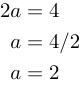

In [ ]:
extract_and_render(r"""
  To solve this, multiply both sides:
$$\begin{aligned} 2a &= 4 \\ a &= 4/2 \\ a &= 2 \end{aligned}$$
""")

In [ ]:
# ============================================================
# Deterministic visual request builder
# ============================================================
# Purpose:
# - Prevent obvious "Draw..." prompts from being rendered as long LaTeX text.
# - Route supported visual tasks directly into matplotlib.
# - Keep current LaTeX solving for non-visual problems.
#
# Supported direct visual patterns:
# - Draw/shade fractions such as 1/3, 1/2, 3/8
# - Draw rectangle with N regions and a fraction shaded
# - Draw A union B for two finite sets
# ============================================================

def _parse_simple_fraction(text: str):
    """
    Finds a simple fraction such as 1/3, 1 / 3, or 3/8.

    Returns:
        (numerator, denominator) or None
    """
    match = re.search(r"(\d+)\s*/\s*(\d+)", text)

    if not match:
        return None

    numerator = int(match.group(1))
    denominator = int(match.group(2))

    if denominator == 0:
        return None

    return numerator, denominator


def _parse_region_count(text: str):
    """
    Finds region count phrases such as:
    - 6 regions
    - six regions

    Returns:
        integer region count or None
    """
    number_words = {
        "one": 1,
        "two": 2,
        "three": 3,
        "four": 4,
        "five": 5,
        "six": 6,
        "seven": 7,
        "eight": 8,
        "nine": 9,
        "ten": 10,
        "twelve": 12
    }

    digit_match = re.search(r"\b(\d+)\s+regions?\b", text, re.IGNORECASE)
    if digit_match:
        return int(digit_match.group(1))

    word_match = re.search(
        r"\b(one|two|three|four|five|six|seven|eight|nine|ten|twelve)\s+regions?\b",
        text,
        re.IGNORECASE
    )

    if word_match:
        return number_words[word_match.group(1).lower()]

    return None


def _parse_pythonish_set_items(set_text: str):
    """
    Parses simple set contents like:
        1,5,6
        a,c,d
        {1, 5, 6}

    Returns:
        list of cleaned string items
    """
    cleaned = set_text.strip()
    cleaned = cleaned.strip("{}")
    items = []

    for item in cleaned.split(","):
        item = item.strip()
        if item:
            items.append(item)

    return items


def _parse_two_sets_for_union(problem: str):
    """
    Parses prompts such as:
        Draw A U B if A = {1,5,6}, B = {a,c,d}

    Returns:
        (A_items, B_items) or None
    """
    pattern = (
        r"A\s*=\s*\{([^}]*)\}"
        r".*?"
        r"B\s*=\s*\{([^}]*)\}"
    )

    match = re.search(pattern, problem, re.IGNORECASE)

    if not match:
        return None

    A_items = _parse_pythonish_set_items(match.group(1))
    B_items = _parse_pythonish_set_items(match.group(2))

    return A_items, B_items


def build_direct_visual_request(problem: str):
    """
    Converts obvious primary-school visual prompts directly into a visual_request.

    Returns:
        visual_request dictionary or None

    This is intentionally rule-based because these prompts are explicit:
    "Draw...", "Show a rectangular shape...", "with 1/2 shaded", etc.
    """

    text = problem.strip()
    lower = text.lower()

    asks_for_visual = any(
        trigger in lower
        for trigger in [
            "draw",
            "shade",
            "shading",
            "rectangular shape",
            "rectangle",
            "number line",
            "venn",
            "a u b",
            "a ∪ b"
        ]
    )

    if not asks_for_visual:
        return None

    # --------------------------------------------------------
    # Case 1: Draw A U B / A union B
    # --------------------------------------------------------
    if ("a u b" in lower or "a ∪ b" in lower or "union" in lower) and "{" in text:
        parsed_sets = _parse_two_sets_for_union(text)

        if parsed_sets:
            A_items, B_items = parsed_sets

            A_set = set(A_items)
            B_set = set(B_items)

            only_A = sorted(A_set - B_set)
            only_B = sorted(B_set - A_set)
            both = sorted(A_set & B_set)

            return {
                "kind": "venn2",
                "subsets": [
                    max(len(only_A), 1),
                    max(len(only_B), 1),
                    len(both)
                ],
                "set_labels": ["A", "B"],
                "title": "A ∪ B",
                "region_labels": {
                    "10": ", ".join(only_A),
                    "01": ", ".join(only_B),
                    "11": ", ".join(both)
                }
            }

    # --------------------------------------------------------
    # Case 2: Rectangle/box grid with N regions and fraction shaded
    # Example:
    # Draw a rectangle having 6 regions inside, with 1/2 shaded
    # --------------------------------------------------------
    if "rectangle" in lower or "rectangular" in lower:
        frac = _parse_simple_fraction(text)
        region_count = _parse_region_count(text)

        if frac and region_count:
            numerator, denominator = frac

            shaded_cells = round(region_count * numerator / denominator)
            shaded_cells = max(0, min(shaded_cells, region_count))

            shaded = [[0, c] for c in range(shaded_cells)]

            return {
                "kind": "box_grid",
                "rows": 1,
                "cols": region_count,
                "shaded": shaded,
                "title": f"Rectangle divided into {region_count} equal regions",
                "label": f"{numerator}/{denominator} shaded"
            }

        # If no region count is given, use denominator as the number of parts.
        # Example:
        # Draw a rectangular shape that shows the shading of 1/3
        if frac:
            numerator, denominator = frac

            return {
                "kind": "fraction_bar",
                "total_parts": denominator,
                "shaded_parts": numerator,
                "title": "Fraction Bar / Area Model",
                "label": f"{numerator}/{denominator} shaded"
            }

    # --------------------------------------------------------
    # Case 3: Generic shading fraction
    # Example:
    # Draw a rectangular shape that shows the shading of 1/3
    # --------------------------------------------------------
    if "shade" in lower or "shading" in lower:
        frac = _parse_simple_fraction(text)

        if frac:
            numerator, denominator = frac

            return {
                "kind": "fraction_bar",
                "total_parts": denominator,
                "shaded_parts": numerator,
                "title": "Fraction Bar / Area Model",
                "label": f"{numerator}/{denominator} shaded"
            }

    return None


def maybe_render_direct_visual(problem: str):
    """
    Renders a direct visual request if the problem clearly asks for one.

    Returns:
        True if a visual was rendered.
        False otherwise.
    """
    visual_request = build_direct_visual_request(problem)

    if visual_request is None:
        return False

    print("\n========== Direct Visual Renderer ==========")
    print(f"Detected visual kind: {visual_request.get('kind')}")
    print("Rendering with matplotlib, not LaTeX.")
    print("===========================================\n")

    render_visual_request(visual_request)
    return True

In [ ]:
from google.colab import userdata

OPENROUTER_API_KEY = userdata.get("OPENROUTER_API_KEY")
OPENROUTER_URL = "https://openrouter.ai/api/v1/chat/completions"
OPENROUTER_MODEL = "google/gemini-2.5-flash"


"""
from openai import OpenAI

dashscope_key = userdata.get('DASHSCOPE_API_KEY')
nvidia_key = userdata.get('NVIDIA_KEY')

client = OpenAI(
    api_key=nvidia_key,
    #base_url="https://dashscope-intl.aliyuncs.com/compatible-mode/v1",
    base_url="https://integrate.api.nvidia.com/v1"
)
"""

'\nfrom openai import OpenAI\n\ndashscope_key = userdata.get(\'DASHSCOPE_API_KEY\')\nnvidia_key = userdata.get(\'NVIDIA_KEY\')\n\nclient = OpenAI(\n    api_key=nvidia_key,\n    #base_url="https://dashscope-intl.aliyuncs.com/compatible-mode/v1",\n    base_url="https://integrate.api.nvidia.com/v1"\n)\n'

In [ ]:
def call_openrouter_chat(
    messages: list,
    model: str = OPENROUTER_MODEL,
    max_tokens: int = 4096,
    temperature: float = 0.0,
    timeout: int = 120
) -> str:
    """
    Shared OpenRouter chat helper.

    This replaces the Nvidia/OpenAI-compatible client call.
    It keeps the same system prompts and user prompts used elsewhere.
    """

    if not OPENROUTER_API_KEY:
        raise ValueError(
            "OPENROUTER_API_KEY is missing. Add it to Colab userdata first."
        )

    headers = {
        "Authorization": f"Bearer {OPENROUTER_API_KEY}",
        "Content-Type": "application/json",
    }

    payload = {
        "model": model,
        "messages": messages,
        "max_tokens": max_tokens,
        "temperature": temperature,
    }

    response = requests.post(
        OPENROUTER_URL,
        headers=headers,
        json=payload,
        timeout=timeout
    )

    try:
        response.raise_for_status()
    except requests.exceptions.HTTPError:
        print("OpenRouter request failed.")
        print("Status code:", response.status_code)
        print("Response text:", response.text)
        raise

    data = response.json()

    return data["choices"][0]["message"]["content"]

In [ ]:
SYSTEM_PROMPT = """You are a math solver for a math-rendering notebook pipeline.

Rules:
- Provide all responses in English only.
- Return ONLY valid JSON.
- Do not return markdown fences.
- Do not return prose outside JSON.
- Do not return Python code.
- Do not return HTML.
- Supported visual output is limited to number lines, fraction bars, box grids, and two-set Venn diagrams.

Return exactly one of these response types.

1) For normal step-by-step solving:
{
  "response_type": "latex",
  "answer_latex": "$$\\begin{aligned} ... \\end{aligned}$$"
}

2) For a visual-only primary-school diagram:
{
  "response_type": "visual",
  "visual_request": {
    "kind": "number_line | fraction_bar | box_grid | venn2"
  }
}

3) For a solved answer plus a diagram:
{
  "response_type": "latex_visual",
  "answer_latex": "$$\\begin{aligned} ... \\end{aligned}$$",
  "visual_request": {
    "kind": "number_line | fraction_bar | box_grid | venn2"
  }
}

Supported primary-school visual_request formats:

A) Number line:
{
  "kind": "number_line",
  "min": 0,
  "max": 10,
  "points": [3, 7],
  "jumps": [
    {"start": 3, "end": 7, "label": "3 + 4 = 7"}
  ],
  "title": "Number line"
}

B) Fraction bar / area model:
{
  "kind": "fraction_bar",
  "total_parts": 8,
  "shaded_parts": 3,
  "label": "3/8 shaded",
  "title": "Fraction Bar"
}

C) Box grid / array model:
{
  "kind": "box_grid",
  "rows": 3,
  "cols": 4,
  "shaded": [],
  "cell_labels": [],
  "label": "3 x 4 = 12",
  "title": "Box Grid"
}

D) Two-set Venn diagram:
{
  "kind": "venn2",
  "subsets": [3, 2, 1],
  "set_labels": ["A", "B"],
  "title": "Venn Diagram"
}

Venn subsets rule:
- subsets must be [only_first_set, only_second_set, intersection].

Visual selection rules:
- Use "latex" for ordinary solving.
- Use "latex_visual" when a primary-school drawing would help, especially for sets, fractions, number lines, area models, arrays, and simple box/group models.
- Use "visual" only when the user explicitly asks just to draw/show the visual.
- Do not invent visual data. Use values from the problem.
- If exact diagram values are unclear, use "latex" only.

LaTeX rules:
- For normal solving, put the full math work in answer_latex.
- Wrap everything in $$\\begin{aligned} ... \\end{aligned}$$.
- Use &= for alignment.
- Use \\\\ for new lines.
- Use short \\text{} annotations inside LaTeX when useful.
- No explanation outside the JSON.
"""

def solve_and_render(problem: str, debug: bool = False):
    full_response = call_openrouter_chat(
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": f"Problem: {problem}"}
        ],
        max_tokens=4096,
        temperature=0.0
    )

    if debug:
        print("\n\nRAW MODEL OUTPUT:")
        print(full_response)

    # First try structured JSON output
    parsed = extract_json_block(full_response)

    if parsed is None:
        extract_and_render(full_response)
        return full_response

    render_solver_payload(parsed, fallback_text=full_response)
    return None


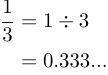

In [ ]:
solve_and_render("Convert 1/3 to decimal")


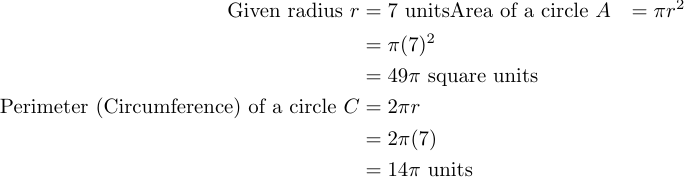

In [ ]:
solve_and_render("Find the area and perimeter of a circle with radius 7")


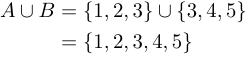

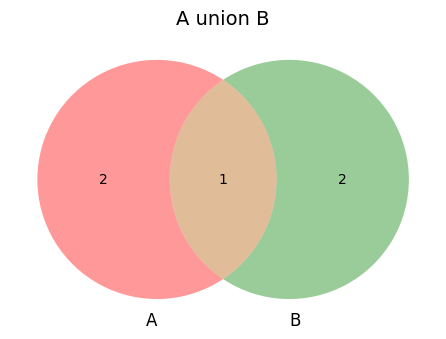

In [ ]:
solve_and_render("Find A union B where A = {1, 2, 3} and B = {3, 4, 5}")

### **--- Elastic Retrieval Setup using requests ---**

In [ ]:
!pip install sentence-transformers python-dotenv

In [ ]:
import requests
import urllib3
from dotenv import load_dotenv
from sentence_transformers import SentenceTransformer

In [ ]:
load_dotenv()

CORPUS_INDEX = "math-corpus-v1"

EMBEDDING_MODEL_NAME = "nvidia/llama-nemotron-embed-vl-1b-v2"
EMBEDDING_DIMS = 2048

# Use Colab secrets first, then .env/env vars.
ELASTIC_HOST = os.getenv("ELASTIC_HOST")

ELASTIC_API_KEY = os.getenv("ELASTIC_API_KEY")
ELASTIC_USER = os.getenv("ELASTIC_USER")
ELASTIC_PASSWORD = os.getenv("ELASTIC_PASSWORD")

ELASTIC_CA_CERT = os.getenv("ELASTIC_CA_CERT")

In [ ]:
ELASTIC_VERIFY_CERTS = os.getenv("ELASTIC_VERIFY_CERTS")

if str(ELASTIC_VERIFY_CERTS) != 'true':
  urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

In [ ]:
def elastic_verify_value():
    """
    Returns the correct verify value for requests.
    - False for tunnel/dev without certificate validation.
    - CA cert path if cert verification is enabled and a CA cert is provided.
    - True if verification is enabled but no CA path is supplied.
    """
    # Convert ELASTIC_VERIFY_CERTS to a boolean
    verify_certs_bool = str(ELASTIC_VERIFY_CERTS).lower() == 'true'

    if not verify_certs_bool: # If verification is explicitly turned off
        return False
    if ELASTIC_CA_CERT:
        return ELASTIC_CA_CERT
    return True


def elastic_headers():
    """
    Builds headers for Elasticsearch requests.
    Supports either API key auth or username/password auth.
    """
    headers = {
        "Content-Type": "application/json",
        "Accept": "application/json"
    }

    if ELASTIC_API_KEY:
        headers["Authorization"] = f"ApiKey {ELASTIC_API_KEY}"

    return headers


def elastic_auth():
    """
    requests auth tuple for username/password.
    If API key is used, return None.
    """
    if ELASTIC_API_KEY:
        return None

    if not ELASTIC_PASSWORD:
        raise RuntimeError(
            "Missing Elasticsearch authentication. "
            "Set ELASTIC_API_KEY or ELASTIC_USER + ELASTIC_PASSWORD."
        )

    return (ELASTIC_USER, ELASTIC_PASSWORD)


def elastic_request(method: str, path: str, body=None, expected=(200, 201)):
    """
    Small requests-based Elasticsearch client.
    """
    if not path.startswith("/"):
        path = "/" + path

    url = ELASTIC_HOST + path

    response = requests.request(
        method=method.upper(),
        url=url,
        headers=elastic_headers(),
        auth=elastic_auth(),
        json=body,
        verify=elastic_verify_value(),
        timeout=120
    )

    if response.status_code not in expected:
        text_preview = response.text[:1000]
        raise RuntimeError(
            f"Elasticsearch request failed.\n"
            f"Method: {method.upper()}\n"
            f"URL: {url}\n"
            f"Status: {response.status_code}\n"
            f"Response preview:\n{text_preview}"
        )

    if response.text.strip():
        try:
            return response.json()
        except Exception:
            return response.text

    return None


def test_elastic_connection():
    info = elastic_request("GET", "/")
    print(f"[OK] Connected to Elasticsearch cluster: {info.get('cluster_name')}")
    print(f"[OK] Elasticsearch version: {info.get('version', {}).get('number')}")
    return info


def test_corpus_index():
    resp = elastic_request("GET", f"/{CORPUS_INDEX}/_count")
    print(f"[OK] {CORPUS_INDEX} document count: {resp['count']}")
    return resp["count"]


test_elastic_connection()
test_corpus_index()

[OK] Connected to Elasticsearch cluster: elasticsearch
[OK] Elasticsearch version: 8.15.1
[OK] math-corpus-v1 document count: 808


808

### **--- Load Nemotron query embedder ---**

In [ ]:
EMBED_DEVICE = os.getenv("EMBED_DEVICE", "cuda")

def load_retrieval_embedding_model():
    print(f"[INFO] Loading retrieval embedding model: {EMBEDDING_MODEL_NAME}")
    print(f"[INFO] Device: {EMBED_DEVICE}")

    try:
        model = SentenceTransformer(
            EMBEDDING_MODEL_NAME,
            trust_remote_code=True,
            device=EMBED_DEVICE
        )
    except Exception:
        if EMBED_DEVICE == "cuda":
            print("[WARN] CUDA load failed. Trying CPU.")
            model = SentenceTransformer(
                EMBEDDING_MODEL_NAME,
                trust_remote_code=True,
                device="cpu"
            )
        else:
            raise

    print("[OK] Retrieval embedding model loaded.")
    return model


def embed_query(text: str) -> list:
    """
    Embeds user problem text for retrieval.
    Keep this separate from document embedding.
    """
    text = (text or "").strip()
    vec = retrieval_embed_model.encode_query([text])[0]

    if len(vec) != EMBEDDING_DIMS:
        raise ValueError(
            f"Embedding dimension mismatch. Expected {EMBEDDING_DIMS}, got {len(vec)}."
        )

    return vec.tolist()


retrieval_embed_model = load_retrieval_embedding_model()

# quick dimension check
_test_vec = embed_query("convert 1/3 to decimal")

print(f"[OK] Query embedding dimension: {len(_test_vec)}")

[INFO] Loading retrieval embedding model: nvidia/llama-nemotron-embed-vl-1b-v2
[INFO] Device: cuda


modules.json:   0%|          | 0.00/277 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/315 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

configuration_llama_nemotron_vl.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/nvidia/llama-nemotron-embed-vl-1b-v2:
- configuration_llama_nemotron_vl.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


modeling_llama_nemotron_vl.py: 0.00B [00:00, ?B/s]

processing_llama_nemotron_vl.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/nvidia/llama-nemotron-embed-vl-1b-v2:
- processing_llama_nemotron_vl.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/nvidia/llama-nemotron-embed-vl-1b-v2:
- modeling_llama_nemotron_vl.py
- processing_llama_nemotron_vl.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


model.safetensors:   0%|          | 0.00/3.36G [00:00<?, ?B/s]

processor_config.json:   0%|          | 0.00/549 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/600 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/91.0 [00:00<?, ?B/s]

[OK] Retrieval embedding model loaded.
[OK] Query embedding dimension: 2048


### **--- Basic kNN Retrieval ---**

In [ ]:
def clean_metadata_value(value: str) -> str:
    value = (value or "").strip().lower()
    value = value.replace(" ", "_")
    value = value.replace("-", "_")
    return value


def retrieve_method_context(
    problem_text: str,
    k: int = 3,
    domain_filter: str = None,
    num_candidates: int = 50
) -> list:
    """
    Embeds the user's problem and retrieves the most relevant instructional pages.

    The returned records are text + metadata only.
    No page image is inserted into the solver prompt.
    """
    query_vector = embed_query(problem_text)

    knn = {
        "field": "embedding",
        "query_vector": query_vector,
        "k": k,
        "num_candidates": num_candidates
    }

    if domain_filter:
        knn["filter"] = {
            "term": {
                "domain": clean_metadata_value(domain_filter)
            }
        }

    body = {
        "knn": knn,
        "_source": [
            "doc_id",
            "filename",
            "topic",
            "domain",
            "pdf_page",
            "content"
        ]
    }

    resp = elastic_request(
        method="POST",
        path=f"/{CORPUS_INDEX}/_search",
        body=body
    )

    results = []

    for hit in resp.get("hits", {}).get("hits", []):
        source = hit.get("_source", {})

        results.append({
            "score": hit.get("_score"),
            "doc_id": source.get("doc_id"),
            "filename": source.get("filename"),
            "topic": source.get("topic"),
            "domain": source.get("domain"),
            "pdf_page": source.get("pdf_page"),
            "content": source.get("content", "")
        })

    return results

### **--- Build Retrieval Context For Prompt ---**

In [ ]:
def build_rag_context(results: list, max_chars_per_result: int = 650) -> str:
    """
    Builds moderate retrieval context.

    This intentionally avoids dumping full PDF pages into the prompt.
    The goal is light method guidance, not over-guidance.
    """
    if not results:
        return ""

    blocks = []

    for i, result in enumerate(results, start=1):
        content_preview = (result.get("content") or "").strip()
        content_preview = content_preview[:max_chars_per_result]

        blocks.append(
            f"[Method Reference {i}]\n"
            f"Doc ID: {result.get('doc_id')}\n"
            f"Topic: {result.get('topic')}\n"
            f"Domain: {result.get('domain')}\n"
            f"Page: {result.get('pdf_page')}\n"
            f"Guidance Excerpt:\n{content_preview}"
        )

    return "\n\n".join(blocks)

In [ ]:
def strip_json_code_fence(text: str) -> str:
    """
    Removes ```json ... ``` or ``` ... ``` fences if the model wraps JSON.
    """
    text = (text or "").strip()

    if text.startswith("```"):
        text = re.sub(r"^```(?:json)?\s*", "", text, flags=re.IGNORECASE)
        text = re.sub(r"\s*```$", "", text)

    return text.strip()


def robust_extract_json_or_latex(raw_response: str):
    """
    More forgiving parser for model outputs.

    It tries:
    1. Existing extract_json_block(), if available.
    2. json.loads() after removing code fences.
    3. Regex extraction of answer_latex if JSON parsing fails.
    """

    raw_response = (raw_response or "").strip()

    # Try your existing parser first, if it exists.
    try:
        parsed = extract_json_block(raw_response)
        if parsed is not None:
            return parsed
    except Exception:
        pass

    cleaned = strip_json_code_fence(raw_response)

    # Try direct JSON parse.
    try:
        return json.loads(cleaned)
    except Exception:
        pass

    # Fallback: extract answer_latex manually.
    # This handles cases where the model returns JSON-looking text
    # but includes raw newlines inside the JSON string.
    match = re.search(
        r'"answer_latex"\s*:\s*"(?P<latex>.*?)"\s*(?:,|\})',
        cleaned,
        flags=re.DOTALL
    )

    if match:
        latex = match.group("latex")

        # Repair common escaped LaTeX sequences.
        latex = latex.replace("\\\\", "\\")
        latex = latex.replace('\\"', '"')

        return {
            "response_type": "latex",
            "answer_latex": latex
        }

    # Fallback: if the response itself contains a LaTeX block.
    latex_match = re.search(
        r"\$\$.*?\$\$",
        raw_response,
        flags=re.DOTALL
    )

    if latex_match:
        return {
            "response_type": "latex",
            "answer_latex": latex_match.group(0)
        }

    return None


def format_retrieval_for_guidance_selection(results: list, max_chars_per_result: int = 900) -> str:
    """
    Formats retrieved documents for the guidance selector LLM.
    This is not the final solver prompt. This is only for selecting useful guidance.
    """

    if not results:
        return "No retrieved method references were found."

    blocks = []

    for i, r in enumerate(results, start=1):
        content = (r.get("content") or "").strip()
        content = content[:max_chars_per_result]

        blocks.append(
            f"[Retrieved Reference {i}]\n"
            f"Score: {r.get('score')}\n"
            f"Doc ID: {r.get('doc_id')}\n"
            f"Topic: {r.get('topic')}\n"
            f"Domain: {r.get('domain')}\n"
            f"Page: {r.get('pdf_page')}\n"
            f"Content:\n{content}"
        )

    return "\n\n".join(blocks)

### **--- RAG Guidance Selector ---**

In [ ]:
# This threshold controls whether retrieved context is considered strong enough
# to be used in the solver prompt.
#
# Tune this after observing your Elasticsearch scores across the 15 test problems.
# Start with 0.70 if your scores are normalized cosine-style scores.
# If your Elasticsearch scores are larger raw values, adjust this after printing scores.
RETRIEVAL_SCORE_THRESHOLD = 0.67


def get_top_retrieval_score(retrieval_results: list) -> float:
    """
    Safely extracts the top Elasticsearch retrieval score.

    Assumption:
    - retrieve_method_context() returns results sorted from strongest to weakest.
    """

    if not retrieval_results:
        return 0.0

    top_result = retrieval_results[0]
    return float(top_result.get("score", 0.0) or 0.0)


def should_use_retrieval(
    retrieval_results: list,
    threshold: float = RETRIEVAL_SCORE_THRESHOLD
) -> bool:
    """
    Deterministic retrieval gate.

    This replaces the old LLM-based use_retrieval decision.

    Instead of asking the LLM whether retrieval should be used, this function
    checks whether the best Elasticsearch score meets a fixed threshold.
    """

    top_score = get_top_retrieval_score(retrieval_results)
    return top_score >= threshold


def empty_retrieval_guidance(
    retrieval_results: list = None,
    reason: str = ""
) -> dict:
    """
    Standard fallback object when retrieval should not be used.
    """

    return {
        "use_retrieval": False,
        "selected_doc_ids": [],
        "method_guidance": "",
        "latex_detail_instruction": "",
        "retrieval_gate_reason": reason,
        "top_retrieval_score": get_top_retrieval_score(retrieval_results or [])
    }


GUIDANCE_SELECTOR_SYSTEM_PROMPT = """
You are a retrieval guidance selector for a math-solving RAG system.

Your task:
- Read the user's math problem.
- Read the retrieved method references.
- Select only the guidance that is directly useful for solving the user's exact problem.
- Ignore irrelevant or loosely related references.
- Do not solve the full problem.
- Do not copy large chunks from the references.
- Produce concise method guidance that can help another solver.
- Keep the guidance moderate, not overly detailed.

Important:
- Do not decide whether retrieval should be used.
- Retrieval has already passed a deterministic Elasticsearch score threshold before this call.
- Your job is only to select and compress useful guidance.

Return only valid JSON in this exact structure:

{
  "selected_doc_ids": ["doc_id_1", "doc_id_2"],
  "method_guidance": "Concise method guidance here.",
  "latex_detail_instruction": "Short instruction for what method detail should appear inside the LaTeX solution."
}
"""


def select_retrieval_guidance(
    problem: str,
    retrieval_results: list,
    debug: bool = False
) -> dict:
    """
    Uses the LLM only to filter and compress RAG output before final solving.

    Important:
    - This function no longer decides use_retrieval.
    - The deterministic Elasticsearch threshold decides that before this function is called.
    """

    if not retrieval_results:
        return empty_retrieval_guidance(
            retrieval_results=[],
            reason="No retrieval results returned."
        )

    references_text = format_retrieval_for_guidance_selection(retrieval_results)

    user_prompt = f"""
User Problem:
{problem}

Retrieved Method References:
{references_text}

Select only the retrieved references that are actually useful.
Return only the required JSON.
"""

    raw = call_openrouter_chat(
      messages=[
          {"role": "system", "content": GUIDANCE_SELECTOR_SYSTEM_PROMPT},
          {"role": "user", "content": user_prompt}
      ],
      max_tokens=2048,
      temperature=0.0
  ).strip()

    if debug:
        print("\n========== Raw Guidance Selector Output ==========")
        print(raw)
        print("=================================================\n")

    parsed = robust_extract_json_or_latex(raw)

    if not isinstance(parsed, dict):
        return empty_retrieval_guidance(
            retrieval_results=retrieval_results,
            reason="Guidance selector did not return valid JSON."
        )

    return {
        # This is now forced to True because this function should only be called
        # after retrieval passes the deterministic score threshold.
        "use_retrieval": True,
        "selected_doc_ids": parsed.get("selected_doc_ids", []),
        "method_guidance": parsed.get("method_guidance", ""),
        "latex_detail_instruction": parsed.get("latex_detail_instruction", ""),
        "retrieval_gate_reason": "Top Elasticsearch score met the fixed threshold.",
        "top_retrieval_score": get_top_retrieval_score(retrieval_results)
    }

In [ ]:
RAG_SYSTEM_AMENDMENT = """

Retrieval context rules:
- If selected retrieval guidance is provided, use it as moderate method guidance only.
- Use the selected guidance to choose the solving method, formula, or reasoning pattern.
- Do not copy retrieved examples unless they exactly match the user's problem.
- Ignore retrieval guidance if it is irrelevant to the user's exact problem.
- The solution must still solve the user's actual problem, not the reference problem.
- Include a small amount of method detail inside the LaTeX solution when useful.
- Method detail should appear as short LaTeX text annotations, for example:
  && \\text{divide numerator by denominator}
  && \\text{apply the area formula}
  && \\text{combine unique elements}
- If the problem benefits from a primary-school visual, return response_type = "latex_visual" and include a supported visual_request.
- Do not add paragraphs outside the required JSON.
- Preserve the required JSON output format exactly.
"""

if "Retrieval context rules:" not in SYSTEM_PROMPT:
    SYSTEM_PROMPT = SYSTEM_PROMPT + RAG_SYSTEM_AMENDMENT

print("[OK] SYSTEM_PROMPT amended for moderate RAG guidance and primary-school visuals.")

[OK] SYSTEM_PROMPT amended for moderate RAG guidance and primary-school visuals.


### **--- RAG-enabled solver wrapper ---**

In [ ]:
def build_solver_user_prompt(problem: str, selected_guidance: dict):
    """
    Builds the final user prompt for the solver.

    Condition A / fallback:
    - No retrieved method guidance is active.

    Condition C:
    - Retrieval passed the fixed Elasticsearch threshold.
    - The solver must visibly use the selected method guidance.
    """

    use_retrieval = selected_guidance.get("use_retrieval", False)
    method_guidance = (selected_guidance.get("method_guidance") or "").strip()
    latex_detail_instruction = (selected_guidance.get("latex_detail_instruction") or "").strip()
    selected_doc_ids = selected_guidance.get("selected_doc_ids", [])

    # ------------------------------------------------------------
    # No retrieval active: behave like direct solving
    # ------------------------------------------------------------
    if not use_retrieval or not method_guidance:
        return f"""
Problem:
{problem}

Condition:
Direct solving. No retrieved method guidance is active.

Instruction:
Solve the user's exact problem.
Return the required JSON format only.
Use response_type = "latex" for normal solving.
Use response_type = "latex_visual" only when a supported primary-school visual helps.
Only use supported primary-school visuals when a diagram is useful.
"""

    # ------------------------------------------------------------
    # Retrieval active: force visible method grounding
    # ------------------------------------------------------------
    return f"""
Problem:
{problem}

Condition:
Threshold-gated RAG solving is active.

Selected Retrieval Guidance:
{method_guidance}

Selected Reference Doc IDs:
{selected_doc_ids}

LaTeX Detail Instruction:
{latex_detail_instruction}

Instruction:
You must use the selected retrieval guidance as the solving method.
The LaTeX solution must visibly include the method step requested in the LaTeX Detail Instruction.
Do not ignore, summarize away, or skip the retrieved method step.
Do not give only the final answer.
Do not skip the method step even if the answer is simple.
Solve the user's exact problem.
Return the required JSON format only.
Use response_type = "latex" for normal solving.
Use response_type = "latex_visual" only when a supported primary-school visual helps.
Only use supported primary-school visuals when a diagram is useful.
"""

### **--- Guidance-to-LaTeX Render Helpers ---**

In [ ]:
def escape_latex_text(text: str) -> str:
    """
    Escapes LaTeX special characters for normal text rendering.
    This is for rendering method guidance beneath the math solution.
    """
    if not text:
        return ""

    replacements = {
        "\\": r"\textbackslash{}",
        "&": r"\&",
        "%": r"\%",
        "$": r"\$",
        "#": r"\#",
        "_": r"\_",
        "{": r"\{",
        "}": r"\}",
        "~": r"\textasciitilde{}",
        "^": r"\textasciicircum{}",
    }

    escaped = []
    for ch in text:
        escaped.append(replacements.get(ch, ch))

    return "".join(escaped)


def split_guidance_into_lines(text: str, max_chars: int = 95) -> list:
    """
    Splits guidance text into readable lines.

    Main strategy:
    - Split after sentence-ending punctuation: . ! ?
    - Avoid splitting common decimal numbers like 0.333 or 3.14159
    - If a sentence is still too long, split softly at commas or conjunctions
    - If there is no punctuation, wrap by word length
    """

    text = (text or "").strip()
    if not text:
        return []

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text)

    # Protect decimal points inside numbers so we do not split 3.14159 or 0.333
    protected = re.sub(
        r"(?<=\d)\.(?=\d)",
        "<DECIMAL_POINT>",
        text
    )

    # Split after sentence punctuation followed by whitespace and a likely new sentence
    # Example: "Do this. Then do that." -> ["Do this.", "Then do that."]
    rough_sentences = re.split(
        r"(?<=[.!?])\s+(?=[A-Z0-9])",
        protected
    )

    # Restore decimals
    rough_sentences = [
        s.replace("<DECIMAL_POINT>", ".").strip()
        for s in rough_sentences
        if s.strip()
    ]

    final_lines = []

    for sentence in rough_sentences:
        if len(sentence) <= max_chars:
            final_lines.append(sentence)
            continue

        # Try softer splitting for long sentences
        soft_parts = re.split(
            r"(?<=,)\s+|(?=\b(?:and|but|so|then|where|because|while)\b)",
            sentence
        )

        buffer = ""

        for part in soft_parts:
            part = part.strip()
            if not part:
                continue

            candidate = f"{buffer} {part}".strip()

            if len(candidate) <= max_chars:
                buffer = candidate
            else:
                if buffer:
                    final_lines.append(buffer)
                buffer = part

        if buffer:
            # If still too long, word-wrap it
            if len(buffer) <= max_chars:
                final_lines.append(buffer)
            else:
                final_lines.extend(word_wrap_text(buffer, max_chars=max_chars))

    return final_lines


def word_wrap_text(text: str, max_chars: int = 95) -> list:
    """
    Word-wraps text into readable chunks.
    Used when punctuation is not enough.
    """
    words = (text or "").split()
    lines = []
    current = ""

    for word in words:
        candidate = f"{current} {word}".strip()

        if len(candidate) <= max_chars:
            current = candidate
        else:
            if current:
                lines.append(current)
            current = word

    if current:
        lines.append(current)

    return lines


def latex_guidance_block(title: str, text: str, max_chars: int = 95) -> str:
    """
    Converts guidance text into a readable LaTeX block.

    Output style:
        Method guidance:
        • First sentence.
        • Second sentence.
    """
    lines = split_guidance_into_lines(text, max_chars=max_chars)

    if not lines:
        return ""

    latex_lines = [
        r"\noindent\textbf{" + escape_latex_text(title) + r":}\\"
    ]

    latex_lines.append(r"\begin{itemize}")

    for line in lines:
        latex_lines.append(
            r"\item " + escape_latex_text(line)
        )

    latex_lines.append(r"\end{itemize}")

    return "\n".join(latex_lines)


def append_method_guidance_to_latex(
    answer_latex: str,
    method_guidance: str = "",
    latex_detail_instruction: str = "",
    include_detail_instruction: bool = True
) -> str:
    """
    Appends selected method guidance beneath the LaTeX solution.

    This version formats guidance into readable lines/list items instead of
    rendering everything as one long paragraph.
    """
    answer_latex = (answer_latex or "").strip()
    method_guidance = (method_guidance or "").strip()
    latex_detail_instruction = (latex_detail_instruction or "").strip()

    blocks = []

    method_block = latex_guidance_block(
        title="Method guidance",
        text=method_guidance,
        max_chars=95
    )

    if method_block:
        blocks.append(method_block)

    if include_detail_instruction:
        detail_block = latex_guidance_block(
            title="LaTeX detail instruction used",
            text=latex_detail_instruction,
            max_chars=95
        )

        if detail_block:
            blocks.append(detail_block)

    if not blocks:
        return answer_latex

    guidance_text = "\n\n".join(blocks)

    combined = (
        f"{answer_latex}\n\n"
        r"\vspace{8pt}" "\n\n"
        f"{guidance_text}"
    )

    return combined

In [ ]:
def solve_and_render_rag(
    problem: str,
    k: int = 3,
    domain_filter: str = None,
    debug: bool = False,
    show_retrieval: bool = True,
    show_guidance: bool = True,
    return_payload: bool = False,
    visual_fast_path: bool = True,
    strict_full_pipeline: bool = False
):
    """
    Full retrieval + guidance selection + solver path.

    Default behavior:
    - If the problem is an obvious supported visual task, render the visual directly.
    - This avoids wasting time asking the LLM to create LaTeX for a drawing task.
    - For strict thesis Condition C testing, set strict_full_pipeline=True.

    Pipeline:
    1. Retrieve method context from Elasticsearch.
    2. For obvious visual tasks, optionally render matplotlib visual directly.
    3. Otherwise ask LLM to select relevant guidance.
    4. Send problem + selected guidance to solver.
    5. Render LaTeX and/or supported primary-school visuals.
    """

    retrieval_results = retrieve_method_context(
        problem_text=problem,
        k=k,
        domain_filter=domain_filter
    )

    if show_retrieval:
        print("\n========== Retrieved Method Context ==========")
        if retrieval_results:
            for result in retrieval_results:
                print(
                    f"Score: {result.get('score')} | "
                    f"Topic: {result.get('topic')} | "
                    f"Domain: {result.get('domain')} | "
                    f"Doc: {result.get('doc_id')}"
                )
        else:
            print("[WARN] No retrieval context found.")
        print("=============================================\n")

    # --------------------------------------------------------
    # Fast visual path
    # --------------------------------------------------------
    # This is the important fix.
    #
    # If the prompt says "Draw..." and it matches a supported
    # primary-school visual, do not let the LLM turn it into a
    # long LaTeX sentence. Render the matplotlib visual directly.
    #
    # For strict thesis Condition C testing, set:
    #     strict_full_pipeline=True
    # --------------------------------------------------------

    direct_visual_request = build_direct_visual_request(problem)

    if visual_fast_path and direct_visual_request is not None and not strict_full_pipeline:
        payload = {
            "retrieval_results": retrieval_results,
            "selected_guidance": None,
            "raw_response": None,
            "parsed": {
                "response_type": "visual",
                "visual_request": direct_visual_request
            },
            "visual_fast_path_used": True
        }

        print("\n========== Direct Visual Renderer ==========")
        print(f"Detected visual kind: {direct_visual_request.get('kind')}")
        print("Skipped guidance selector and solver LLM for this visual-only prompt.")
        print("Rendering with matplotlib.")
        print("===========================================\n")

        render_visual_request(direct_visual_request)

        return payload if return_payload else None


    top_score = get_top_retrieval_score(retrieval_results)
    retrieval_allowed = should_use_retrieval(retrieval_results)

    if not retrieval_allowed:
        selected_guidance = empty_retrieval_guidance(
            retrieval_results=retrieval_results,
            reason=(
                f"Top Elasticsearch score {top_score:.4f} was below "
                f"threshold {RETRIEVAL_SCORE_THRESHOLD:.4f}."
            )
        )

        if show_guidance:
            print("\n========== Retrieval Gate ==========")
            print(f"Top retrieval score: {top_score}")
            print(f"Threshold: {RETRIEVAL_SCORE_THRESHOLD}")
            print("Use retrieval: False")
            print("Skipped guidance selector LLM call.")
            print("===================================\n")

    else:
        selected_guidance = select_retrieval_guidance(
            problem=problem,
            retrieval_results=retrieval_results,
            debug=debug
        )

        if show_guidance:
            print("\n========== Retrieval Gate ==========")
            print(f"Top retrieval score: {top_score}")
            print(f"Threshold: {RETRIEVAL_SCORE_THRESHOLD}")
            print("Use retrieval: True")
            print("Retreival score satisfied.")
            print("===================================\n")

    if show_guidance:
        print("\n========== Selected Retrieval Guidance ==========")
        print(f"Use retrieval: {selected_guidance.get('use_retrieval')}")
        print(f"Selected docs: {selected_guidance.get('selected_doc_ids')}")
        print(f"Method guidance: {selected_guidance.get('method_guidance')}")
        print(f"LaTeX detail instruction: {selected_guidance.get('latex_detail_instruction')}")
        print("================================================\n")

    user_prompt = build_solver_user_prompt(
        problem=problem,
        selected_guidance=selected_guidance
    )

    full_response = call_openrouter_chat(
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": user_prompt}
        ],
        max_tokens=4096,
        temperature=0.0
    )

    if debug:
      print("\n========== Final Solver User Prompt ==========")
      print(user_prompt)
      print("=============================================\n")

    parsed = robust_extract_json_or_latex(full_response)

    payload = {
        "retrieval_results": retrieval_results,
        "selected_guidance": selected_guidance,
        "raw_response": full_response,
        "parsed": parsed,
        "visual_fast_path_used": False
    }

    if parsed is not None:
        if parsed.get("response_type") == "latex":
            latex = parsed.get("answer_latex", "")

            if not latex.strip():
                print("JSON found, but no answer_latex field was returned.")
                print(parsed)
                return payload if return_payload else None

            renderable_latex = append_method_guidance_to_latex(
                answer_latex=latex,
                method_guidance=selected_guidance.get("method_guidance", ""),
                latex_detail_instruction=selected_guidance.get("latex_detail_instruction", "")
            )

            extract_and_render(renderable_latex)
            return payload if return_payload else None

        render_solver_payload(parsed, fallback_text=full_response)
        return payload if return_payload else None

    extract_and_render(full_response)
    return payload if return_payload else None


========== Retrieved Method Context ==========
Score: 0.67839384 | Topic: c_converting_fractions_decimals | Domain: fractions-decimals | Doc: fractions-decimals__c_converting_fractions_decimals-p001
Score: 0.6770077 | Topic: f_fraction_decimal_chart | Domain: fractions-decimals | Doc: fractions-decimals__f_fraction_decimal_chart-p001
Score: 0.67157364 | Topic: d_decimal_fraction_percentage | Domain: fractions-decimals | Doc: fractions-decimals__d_decimal_fraction_percentage-p001


========== Retrieval Gate ==========
Top retrieval score: 0.67839384
Threshold: 0.67
Use retrieval: True
Retreival score satisfied.


========== Selected Retrieval Guidance ==========
Use retrieval: True
Selected docs: ['fractions-decimals__c_converting_fractions_decimals-p001']
Method guidance: To convert a fraction to a decimal, divide the numerator by the denominator. The result can be a terminating or repeating decimal.
LaTeX detail instruction: Show the long division of 1 by 3 to convert the fraction to


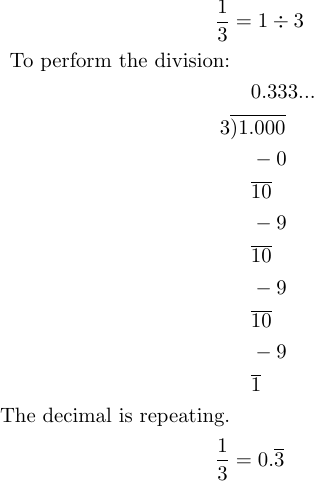

In [ ]:
solve_and_render_rag("Convert 1/3 to decimal")


========== Retrieved Method Context ==========
Score: 0.7100291 | Topic: m_mensuration | Domain: area-perimeter | Doc: area-perimeter__m_mensuration-p002
Score: 0.70722365 | Topic: p_perimeter | Domain: area-perimeter | Doc: area-perimeter__p_perimeter-p002
Score: 0.69905686 | Topic: a_area_circle | Domain: area-perimeter | Doc: area-perimeter__a_area_circle-p001


========== Retrieval Gate ==========
Top retrieval score: 0.7100291
Threshold: 0.67
Use retrieval: True
Retreival score satisfied.


========== Selected Retrieval Guidance ==========
Use retrieval: True
Selected docs: ['area-perimeter__m_mensuration-p002', 'area-perimeter__a_area_circle-p001']
Method guidance: To find the area and perimeter (circumference) of a circle, use the standard mensuration formulas. The area of a circle is given by A = πr², and the circumference is given by C = 2πr, where 'r' is the radius of the circle.
LaTeX detail instruction: Show the formulas for the area and circumference of a circle, substitu


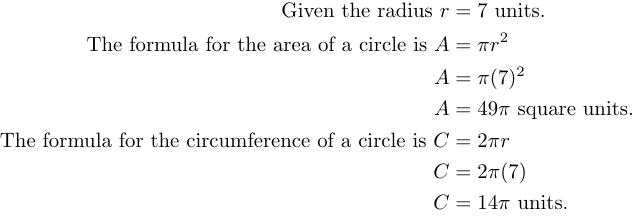

In [ ]:
solve_and_render_rag("Find the area and perimeter of a circle with radius 7")


========== Retrieved Method Context ==========
Score: 0.74476886 | Topic: u_union | Domain: set-theory | Doc: set-theory__u_union-p002
Score: 0.7271805 | Topic: u_union | Domain: set-theory | Doc: set-theory__u_union-p001
Score: 0.71938896 | Topic: u_union | Domain: set-theory | Doc: set-theory__u_union-p003


========== Retrieval Gate ==========
Top retrieval score: 0.74476886
Threshold: 0.67
Use retrieval: True
Retreival score satisfied.


========== Selected Retrieval Guidance ==========
Use retrieval: True
Selected docs: ['set-theory__u_union-p002', 'set-theory__u_union-p001']
Method guidance: To find the union of two sets A and B, combine all unique elements from both sets. List each element only once, even if it appears in both sets. The union is denoted by the symbol '∪'.
LaTeX detail instruction: Define the union of sets A and B as the set of all elements x such that x is in A OR x is in B. Then, list the elements of A and B, and combine them into the union set, ensuring no du


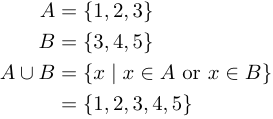

In [ ]:
solve_and_render_rag("Find A union B where A = {1, 2, 3} and B = {3, 4, 5}")


========== Retrieved Method Context ==========
Score: 0.68041825 | Topic: v_venn_diagrams | Domain: set-theory | Doc: set-theory__v_venn_diagrams-p001
Score: 0.6775894 | Topic: i_intersection_sets | Domain: set-theory | Doc: set-theory__i_intersection_sets-p002
Score: 0.674319 | Topic: v_venn_diagrams | Domain: set-theory | Doc: set-theory__v_venn_diagrams-p002


========== Retrieval Gate ==========
Top retrieval score: 0.68041825
Threshold: 0.67
Use retrieval: True
Retreival score satisfied.


========== Selected Retrieval Guidance ==========
Use retrieval: True
Selected docs: ['set-theory__v_venn_diagrams-p001', 'set-theory__v_venn_diagrams-p002', 'set-theory__i_intersection_sets-p002']
Method guidance: To draw a Venn diagram for A U B, first define the sets A and B based on the problem's criteria. Then, identify the elements that are common to both sets (the intersection) and place them in the overlapping region of the Venn diagram. Next, place the unique elements of set A in its n


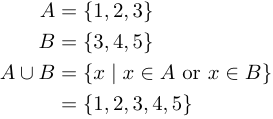

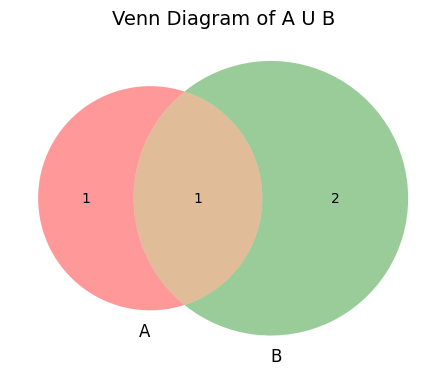

In [ ]:
solve_and_render_rag("Draw a venn diagram of A U B for all even numbers less than 10")


========== Retrieved Method Context ==========
Score: 0.7599752 | Topic: n_number_line | Domain: number-types | Doc: number-types__n_number_line-p001
Score: 0.6805601 | Topic: n_negative_number | Domain: number-types | Doc: number-types__n_negative_number-p003
Score: 0.67952037 | Topic: n_number_line | Domain: number-types | Doc: number-types__n_number_line-p002


========== Retrieval Gate ==========
Top retrieval score: 0.7599752
Threshold: 0.67
Use retrieval: True
Retreival score satisfied.


========== Selected Retrieval Guidance ==========
Use retrieval: True
Selected docs: ['number-types__n_number_line-p001', 'number-types__n_number_line-p003']
Method guidance: To draw a number line from -5 to 5, first draw a horizontal line. Then, mark integer values from -5 to 5 on this line. Ensure that negative numbers are to the left of zero and positive numbers are to the right.
LaTeX detail instruction: Draw a horizontal number line with tick marks for integers from -5 to 5, labeling each 

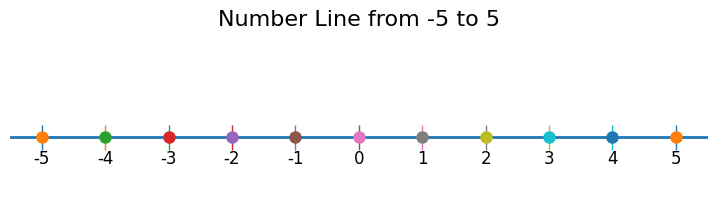

In [ ]:
solve_and_render_rag("Draw a number line of -5 to 5")

### --- **15 Question Condition Test** ---

In [ ]:
# ------------------------------------------------------------
# 1. 15-problem thesis test set
# ------------------------------------------------------------

THESIS_TEST_PROBLEMS = [
    {
        "id": "P01",
        "problem": "Add 1/2 + 1/5",
        "expected_area": "fractions"
    },
    {
        "id": "P02",
        "problem": "Multiply 3/4 by 2/5",
        "expected_area": "fractions"
    },
    {
        "id": "P03",
        "problem": "The fraction 3/4 written as a decimal is",
        "expected_area": "fractions-decimals"
    },
    {
        "id": "P04",
        "problem": "If R = {a,b,c,d,e,f}, draw the set that is not a subset of R",
        "expected_area": "set-theory"
    },
    {
        "id": "P05",
        "problem": "Draw a rectangular shape that shows the shading of 1/3",
        "expected_area": "fractions-visuals"
    },
    {
        "id": "P06",
        "problem": "Show that 3 * 7 + 3 * 9 is the same as 7 + 7 + 7 + 9 + 9 + 9",
        "expected_area": "multiplication"
    },
    {
        "id": "P07",
        "problem": "In a proper fraction, the difference between the numerator and denominator is 5. If the denominator is 7, what is the fraction?",
        "expected_area": "fractions"
    },
    {
        "id": "P08",
        "problem": "What is 1/8 of 16",
        "expected_area": "fractions"
    },
    {
        "id": "P09",
        "problem": "The sum of 0.5 and 1.7 is",
        "expected_area": "decimals"
    },
    {
        "id": "P10",
        "problem": "The top length is a square is 7cm, what is the perimeter?",
        "expected_area": "perimeter"
    },
    {
        "id": "P11",
        "problem": "Show the largest to the smallest fraction and why they are so, 1/2, 1/4, 1/3, 1/5",
        "expected_area": "fractions-ordering"
    },
    {
        "id": "P12",
        "problem": "Draw A U B if A = {1,5,6}, B = {a,c,d}",
        "expected_area": "set-theory"
    },
    {
        "id": "P13",
        "problem": "Set A = {Even prime numbers greater than 2}, how many members does set A have?",
        "expected_area": "set-theory"
    },
    {
        "id": "P14",
        "problem": "Draw a rectangle having 6 regions inside, with 1/2 shaded",
        "expected_area": "fractions-visuals"
    },
    {
        "id": "P15",
        "problem": "The mixed number 7 2/5 written as an improper fraction is",
        "expected_area": "mixed-numbers"
    },
]


# ------------------------------------------------------------
# 2. Small display helpers for clean notebook output
# ------------------------------------------------------------

def print_condition_header(condition_code: str, condition_name: str, problem_id: str, problem: str):
    print("\n" + "=" * 90)
    print(f"CONDITION {condition_code}: {condition_name}")
    print(f"Problem ID: {problem_id}")
    print(f"Problem: {problem}")
    print("=" * 90 + "\n")


def print_subsection(title: str):
    print("\n" + "-" * 90)
    print(title)
    print("-" * 90 + "\n")


# ------------------------------------------------------------
# 3. Condition B helper:
#    Retrieval-backed classification only.
#
# Important thesis logic:
# - Since the original LLM classifier was substituted by Elasticsearch
#   cosine-similarity results, we use the top Elasticsearch hit as the
#   predicted topic/domain label.
# - However, this condition DOES NOT pass the retrieved content/method
#   cards into the solver.
# - It only passes metadata such as predicted topic and predicted domain.
# ------------------------------------------------------------

def infer_problem_type_from_elasticsearch(
    problem: str,
    k: int = 3,
    domain_filter: str = None,
    show_results: bool = True
) -> dict:
    """
    Uses Elasticsearch results as the substituted classification signal.

    Returns:
    {
        "predicted_topic": ...,
        "predicted_domain": ...,
        "top_doc_id": ...,
        "top_score": ...,
        "raw_results": [...]
    }

    This function is used for Condition B only.
    It does not return method guidance.
    It does not pass content into the solver.
    """

    results = retrieve_method_context(
        problem_text=problem,
        k=k,
        domain_filter=domain_filter
    )

    if show_results:
        print_subsection("Classification Signal from Elasticsearch")
        if results:
            for result in results:
                print(
                    f"Score: {result.get('score')} | "
                    f"Topic: {result.get('topic')} | "
                    f"Domain: {result.get('domain')} | "
                    f"Doc: {result.get('doc_id')}"
                )
        else:
            print("[WARN] No Elasticsearch classification signal found.")

    if not results:
        return {
            "predicted_topic": None,
            "predicted_domain": None,
            "top_doc_id": None,
            "top_score": None,
            "raw_results": []
        }

    top = results[0]

    return {
        "predicted_topic": top.get("topic"),
        "predicted_domain": top.get("domain"),
        "top_doc_id": top.get("doc_id"),
        "top_score": top.get("score"),
        "raw_results": results
    }


def build_classification_only_prompt(problem: str, classification_info: dict) -> str:
    """
    Builds the Condition B prompt.

    This prompt includes only the predicted type/domain metadata.
    It does not include retrieved content.
    It does not include selected method guidance.
    """

    predicted_topic = classification_info.get("predicted_topic")
    predicted_domain = classification_info.get("predicted_domain")

    return f"""
Problem:
{problem}

Predicted Problem Type:
{predicted_topic}

Predicted Domain:
{predicted_domain}

Instruction:
Solve the user's exact problem.
Use the predicted problem type/domain only as routing context.
Do not assume any retrieved example or method card.
Do not mention Elasticsearch.
Return the required JSON format only.
Use response_type = "latex" for normal solving.
Use response_type = "latex_visual" only when a supported primary-school visual helps.
Only use supported primary-school visuals when a diagram is useful.
"""


def solve_and_render_classification_only(
    problem: str,
    k: int = 3,
    domain_filter: str = None,
    debug: bool = False,
    show_classification: bool = True,
    return_payload: bool = False
):
    """
    Condition B solver.

    Steps:
    1. Uses Elasticsearch top-k results only to infer topic/domain.
    2. Passes predicted topic/domain metadata to the solver.
    3. Does not pass retrieved content.
    4. Does not run guidance selection.
    5. Renders LaTeX and/or primary-school visuals.
    """

    classification_info = infer_problem_type_from_elasticsearch(
        problem=problem,
        k=k,
        domain_filter=domain_filter,
        show_results=show_classification
    )

    user_prompt = build_classification_only_prompt(
        problem=problem,
        classification_info=classification_info
    )

    full_response = call_openrouter_chat(
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": user_prompt}
        ],
        max_tokens=4096,
        temperature=0.0
    )

    if debug:
        print_subsection("Raw Condition B Solver Output")
        print(full_response)

    parsed = robust_extract_json_or_latex(full_response)

    payload = {
        "condition": "B",
        "classification_info": classification_info,
        "raw_response": full_response,
        "parsed": parsed
    }

    if parsed is not None:
        render_solver_payload(parsed, fallback_text=full_response)
    else:
        extract_and_render(full_response)

    return payload if return_payload else None


# ------------------------------------------------------------
# 4. Condition runner for one problem
# ------------------------------------------------------------

def run_thesis_condition(
    problem_record: dict,
    condition: str,
    k: int = 3,
    domain_filter: str = None,
    debug: bool = False,
    return_payload: bool = False
):
    """
    Runs one thesis condition on one problem.

    condition:
        "A" = Baseline solve_and_render()
        "B" = Classification-only solve_and_render_classification_only()
        "C" = Full pipeline solve_and_render_rag()
    """

    problem_id = problem_record["id"]
    problem = problem_record["problem"]

    condition = condition.upper().strip()

    if condition == "A":
        print_condition_header(
            condition_code="A",
            condition_name="Baseline: Direct LLM, no classification, no retrieval, no guidance",
            problem_id=problem_id,
            problem=problem
        )

        # Baseline uses your existing solve_and_render().
        # This does not call Elasticsearch or RAG.
        result = solve_and_render(problem, debug=debug)

        return result if return_payload else None

    elif condition == "B":
        print_condition_header(
            condition_code="B",
            condition_name="Classification Only: Topic/domain metadata, no method card guidance",
            problem_id=problem_id,
            problem=problem
        )

        result = solve_and_render_classification_only(
            problem=problem,
            k=k,
            domain_filter=domain_filter,
            debug=debug,
            show_classification=True,
            return_payload=return_payload
        )

        return result if return_payload else None

    elif condition == "C":
        print_condition_header(
            condition_code="C",
            condition_name="Full Pipeline: Classification/retrieval, guidance selection, method-conditioned solve",
            problem_id=problem_id,
            problem=problem
        )

        result = solve_and_render_rag(
            problem=problem,
            k=k,
            domain_filter=domain_filter,
            debug=debug,
            show_retrieval=True,
            show_guidance=True,
            return_payload=return_payload
        )

        return result if return_payload else None

    else:
        raise ValueError("condition must be 'A', 'B', or 'C'.")


# ------------------------------------------------------------
# 5. Batch runners
# ------------------------------------------------------------

def run_all_problems_for_condition(
    condition: str,
    problems: list = None,
    k: int = 3,
    domain_filter: str = None,
    debug: bool = False,
    return_payloads: bool = False
):
    """
    Runs all 15 problems under one condition.

    Recommended thesis workflow:
    1. Run all Condition A.
    2. Save/observe outputs.
    3. Run all Condition B.
    4. Save/observe outputs.
    5. Run all Condition C.
    """

    problems = problems or THESIS_TEST_PROBLEMS
    condition = condition.upper().strip()

    payloads = []

    print("\n" + "#" * 100)
    print(f"STARTING CONDITION {condition} TEST RUN")
    print(f"Total problems: {len(problems)}")
    print("#" * 100 + "\n")

    for idx, problem_record in enumerate(problems, start=1):
        print("\n" + "#" * 100)
        print(f"Running problem {idx}/{len(problems)}")
        print("#" * 100 + "\n")

        payload = run_thesis_condition(
            problem_record=problem_record,
            condition=condition,
            k=k,
            domain_filter=domain_filter,
            debug=debug,
            return_payload=return_payloads
        )

        if return_payloads:
            payloads.append({
                "problem_id": problem_record["id"],
                "problem": problem_record["problem"],
                "condition": condition,
                "payload": payload
            })

    print("\n" + "#" * 100)
    print(f"FINISHED CONDITION {condition} TEST RUN")
    print("#" * 100 + "\n")

    return payloads if return_payloads else None


def run_single_problem_all_conditions(
    problem_number: int,
    k: int = 3,
    domain_filter: str = None,
    debug: bool = False
):
    """
    Runs Conditions A, B, and C on one problem.

    problem_number is 1-based.
    Example:
        run_single_problem_all_conditions(1)
    """

    problem_record = THESIS_TEST_PROBLEMS[problem_number - 1]

    for condition in ["A", "B", "C"]:
        run_thesis_condition(
            problem_record=problem_record,
            condition=condition,
            k=k,
            domain_filter=domain_filter,
            debug=debug,
            return_payload=False
        )


# ------------------------------------------------------------
# 6. Optional: create a blank evaluation sheet structure
#
# This does not grade automatically.
# It gives you a manual scoring table structure for thesis notes.
# ------------------------------------------------------------

THESIS_EVALUATION_CRITERIA = [
    "final_answer_correct",
    "steps_clear",
    "latex_rendered_correctly",
    "visual_used_when_helpful",
    "visual_correct",
    "retrieval_or_classification_relevant",
    "notes"
]


def make_blank_evaluation_rows():
    """
    Creates a simple list of dictionaries that can later be converted
    to a DataFrame for manual thesis scoring.
    """

    rows = []

    for problem_record in THESIS_TEST_PROBLEMS:
        for condition in ["A", "B", "C"]:
            row = {
                "problem_id": problem_record["id"],
                "problem": problem_record["problem"],
                "expected_area": problem_record["expected_area"],
                "condition": condition,
            }

            for criterion in THESIS_EVALUATION_CRITERIA:
                row[criterion] = ""

            rows.append(row)

    return rows


print("[OK] Thesis condition test harness loaded.")
print("Use run_all_problems_for_condition('A'), run_all_problems_for_condition('B'), and run_all_problems_for_condition('C').")

[OK] Thesis condition test harness loaded.
Use run_all_problems_for_condition('A'), run_all_problems_for_condition('B'), and run_all_problems_for_condition('C').


### --- **Threshold inspection helper** ---

In [ ]:
# ------------------------------------------------------------
# Threshold inspection helper
# ------------------------------------------------------------
# Run this before final testing to see what Elasticsearch scores
# your 15 thesis problems are producing.
# ------------------------------------------------------------

def inspect_retrieval_scores_for_test_set(
    problems=THESIS_TEST_PROBLEMS,
    k: int = 3,
    domain_filter: str = None
):
    rows = []

    for item in problems:
        problem_id = item["id"]
        problem = item["problem"]
        expected_area = item.get("expected_area")

        results = retrieve_method_context(
            problem_text=problem,
            k=k,
            domain_filter=domain_filter
        )

        top_score = get_top_retrieval_score(results)
        use_retrieval = should_use_retrieval(results)

        top_topic = results[0].get("topic") if results else None
        top_domain = results[0].get("domain") if results else None
        top_doc_id = results[0].get("doc_id") if results else None

        rows.append({
            "id": problem_id,
            "problem": problem,
            "expected_area": expected_area,
            "top_score": top_score,
            "use_retrieval": use_retrieval,
            "top_topic": top_topic,
            "top_domain": top_domain,
            "top_doc_id": top_doc_id
        })

    return rows


score_rows = inspect_retrieval_scores_for_test_set()

for row in score_rows:
    print(
        f"{row['id']} | "
        f"score={row['top_score']:.4f} | "
        f"use_retrieval={row['use_retrieval']} | "
        f"expected={row['expected_area']} | "
        f"topic={row['top_topic']} | "
        f"doc={row['top_doc_id']}"
    )

P01 | score=0.6909 | use_retrieval=True | expected=fractions | topic=m_mixed_number | doc=fractions-decimals__m_mixed_number-p002
P02 | score=0.7010 | use_retrieval=True | expected=fractions | topic=e_equivalent_fractions | doc=fractions-decimals__e_equivalent_fractions-p002
P03 | score=0.7162 | use_retrieval=True | expected=fractions-decimals | topic=d_decimal_fraction_percentage | doc=fractions-decimals__d_decimal_fraction_percentage-p001
P04 | score=0.6703 | use_retrieval=True | expected=set-theory | topic=s_subset | doc=set-theory__s_subset-p002
P05 | score=0.6186 | use_retrieval=False | expected=fractions-visuals | topic=f_fraction_number_line | doc=fractions-decimals__f_fraction_number_line-p001
P06 | score=0.6264 | use_retrieval=False | expected=multiplication | topic=e_exponentiation | doc=arithmetic-operations__e_exponentiation-p001
P07 | score=0.7714 | use_retrieval=True | expected=fractions | topic=p_proper_fraction | doc=fractions-decimals__p_proper_fraction-p002
P08 | scor


####################################################################################################
STARTING CONDITION A TEST RUN
Total problems: 15
####################################################################################################


####################################################################################################
Running problem 1/15
####################################################################################################


CONDITION A: Baseline: Direct LLM, no classification, no retrieval, no guidance
Problem ID: P01
Problem: Add 1/2 + 1/5




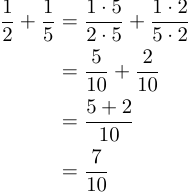


####################################################################################################
Running problem 2/15
####################################################################################################


CONDITION A: Baseline: Direct LLM, no classification, no retrieval, no guidance
Problem ID: P02
Problem: Multiply 3/4 by 2/5




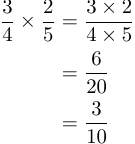


####################################################################################################
Running problem 3/15
####################################################################################################


CONDITION A: Baseline: Direct LLM, no classification, no retrieval, no guidance
Problem ID: P03
Problem: The fraction 3/4 written as a decimal is




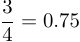


####################################################################################################
Running problem 4/15
####################################################################################################


CONDITION A: Baseline: Direct LLM, no classification, no retrieval, no guidance
Problem ID: P04
Problem: If R = {a,b,c,d,e,f}, draw the set that is not a subset of R




####################################################################################################
Running problem 5/15
####################################################################################################


CONDITION A: Baseline: Direct LLM, no classification, no retrieval, no guidance
Problem ID: P05
Problem: Draw a rectangular shape that shows the shading of 1/3



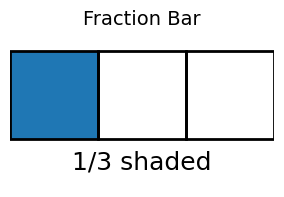


####################################################################################################
Running problem 6/15
####################################################################################################


CONDITION A: Baseline: Direct LLM, no classification, no retrieval, no guidance
Problem ID: P06
Problem: Show that 3 * 7 + 3 * 9 is the same as 7 + 7 + 7 + 9 + 9 + 9




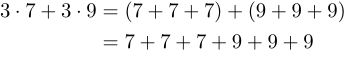


####################################################################################################
Running problem 7/15
####################################################################################################


CONDITION A: Baseline: Direct LLM, no classification, no retrieval, no guidance
Problem ID: P07
Problem: In a proper fraction, the difference between the numerator and denominator is 5. If the denominator is 7, what is the fraction?




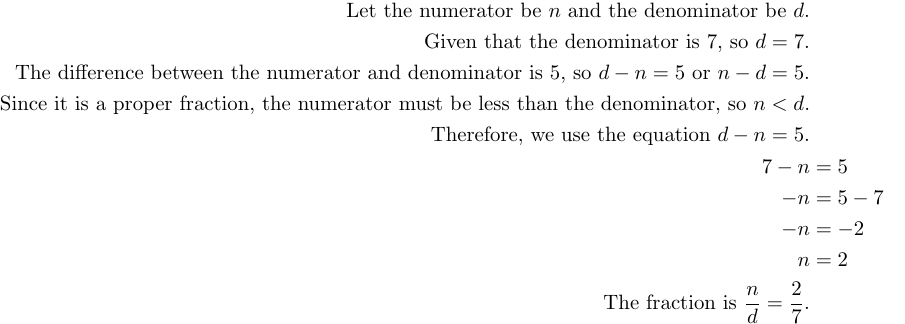


####################################################################################################
Running problem 8/15
####################################################################################################


CONDITION A: Baseline: Direct LLM, no classification, no retrieval, no guidance
Problem ID: P08
Problem: What is 1/8 of 16




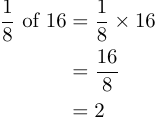


####################################################################################################
Running problem 9/15
####################################################################################################


CONDITION A: Baseline: Direct LLM, no classification, no retrieval, no guidance
Problem ID: P09
Problem: The sum of 0.5 and 1.7 is




####################################################################################################
Running problem 10/15
####################################################################################################


CONDITION A: Baseline: Direct LLM, no classification, no retrieval, no guidance
Problem ID: P10
Problem: The top length is a square is 7cm, what is the perimeter?




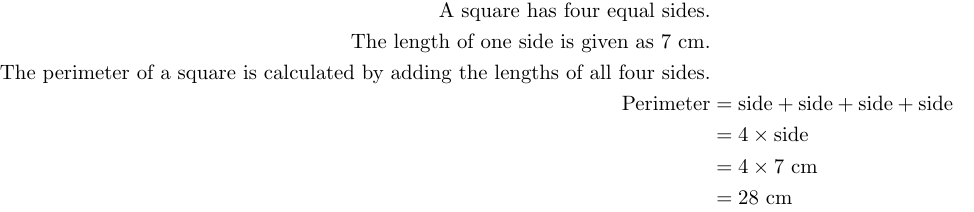


####################################################################################################
Running problem 11/15
####################################################################################################


CONDITION A: Baseline: Direct LLM, no classification, no retrieval, no guidance
Problem ID: P11
Problem: Show the largest to the smallest fraction and why they are so, 1/2, 1/4, 1/3, 1/5




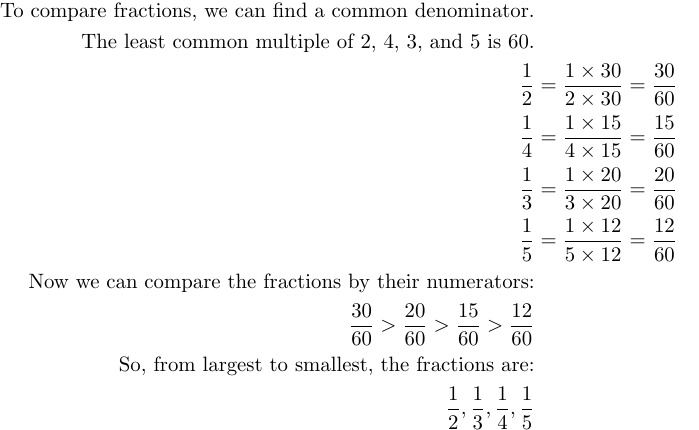


####################################################################################################
Running problem 12/15
####################################################################################################


CONDITION A: Baseline: Direct LLM, no classification, no retrieval, no guidance
Problem ID: P12
Problem: Draw A U B if A = {1,5,6}, B = {a,c,d}




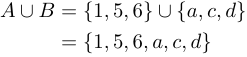


####################################################################################################
Running problem 13/15
####################################################################################################


CONDITION A: Baseline: Direct LLM, no classification, no retrieval, no guidance
Problem ID: P13
Problem: Set A = {Even prime numbers greater than 2}, how many members does set A have?




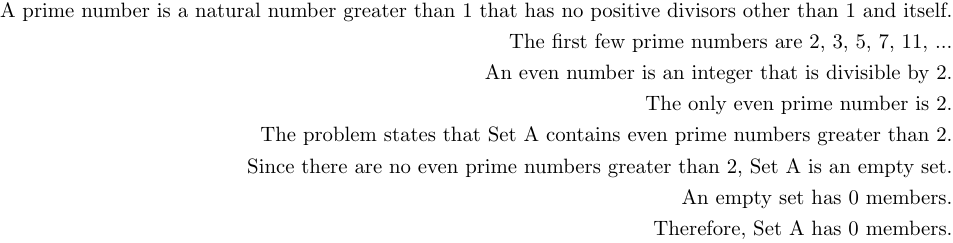


####################################################################################################
Running problem 14/15
####################################################################################################


CONDITION A: Baseline: Direct LLM, no classification, no retrieval, no guidance
Problem ID: P14
Problem: Draw a rectangle having 6 regions inside, with 1/2 shaded



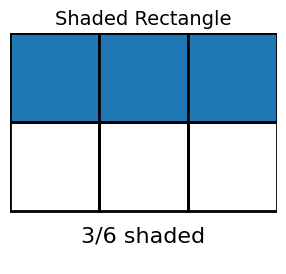


####################################################################################################
Running problem 15/15
####################################################################################################


CONDITION A: Baseline: Direct LLM, no classification, no retrieval, no guidance
Problem ID: P15
Problem: The mixed number 7 2/5 written as an improper fraction is




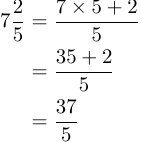


####################################################################################################
FINISHED CONDITION A TEST RUN
####################################################################################################



In [ ]:
run_all_problems_for_condition('A')


####################################################################################################
STARTING CONDITION B TEST RUN
Total problems: 15
####################################################################################################


####################################################################################################
Running problem 1/15
####################################################################################################


CONDITION B: Classification Only: Topic/domain metadata, no method card guidance
Problem ID: P01
Problem: Add 1/2 + 1/5


------------------------------------------------------------------------------------------
Classification Signal from Elasticsearch
------------------------------------------------------------------------------------------

Score: 0.69088745 | Topic: m_mixed_number | Domain: fractions-decimals | Doc: fractions-decimals__m_mixed_number-p002
Score: 0.66497064 | Topic: f_fractions_addition | Domain:


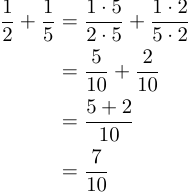


####################################################################################################
Running problem 2/15
####################################################################################################


CONDITION B: Classification Only: Topic/domain metadata, no method card guidance
Problem ID: P02
Problem: Multiply 3/4 by 2/5


------------------------------------------------------------------------------------------
Classification Signal from Elasticsearch
------------------------------------------------------------------------------------------

Score: 0.70102024 | Topic: e_equivalent_fractions | Domain: fractions-decimals | Doc: fractions-decimals__e_equivalent_fractions-p002
Score: 0.67506814 | Topic: m_mixed_number | Domain: fractions-decimals | Doc: fractions-decimals__m_mixed_number-p002
Score: 0.66949725 | Topic: f_fractions_multiplication | Domain: fractions-decimals | Doc: fractions-decimals__f_fractions_multiplication-p002



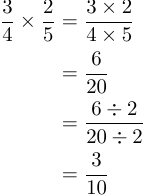


####################################################################################################
Running problem 3/15
####################################################################################################


CONDITION B: Classification Only: Topic/domain metadata, no method card guidance
Problem ID: P03
Problem: The fraction 3/4 written as a decimal is


------------------------------------------------------------------------------------------
Classification Signal from Elasticsearch
------------------------------------------------------------------------------------------

Score: 0.7162106 | Topic: d_decimal_fraction_percentage | Domain: fractions-decimals | Doc: fractions-decimals__d_decimal_fraction_percentage-p001
Score: 0.71258044 | Topic: c_converting_fractions_decimals | Domain: fractions-decimals | Doc: fractions-decimals__c_converting_fractions_decimals-p001
Score: 0.7060766 | Topic: d_decimal | Domain: fractions-decimals | Doc: fractions-decimals__d_decimal-


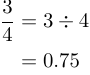


####################################################################################################
Running problem 4/15
####################################################################################################


CONDITION B: Classification Only: Topic/domain metadata, no method card guidance
Problem ID: P04
Problem: If R = {a,b,c,d,e,f}, draw the set that is not a subset of R


------------------------------------------------------------------------------------------
Classification Signal from Elasticsearch
------------------------------------------------------------------------------------------

Score: 0.67028904 | Topic: s_subset | Domain: set-theory | Doc: set-theory__s_subset-p002
Score: 0.668005 | Topic: i_intersection | Domain: set-theory | Doc: set-theory__i_intersection-p002
Score: 0.6619897 | Topic: p_proper_subset | Domain: set-theory | Doc: set-theory__p_proper_subset-p001



####################################################################################################
Running problem 5/15
####################################################################################################


CONDITION B: Classification Only: Topic/domain metadata, no method card guidance
Problem ID: P05
Problem: Draw a rectangular shape that shows the shading of 1/3


------------------------------------------------------------------------------------------
Classification Signal from Elasticsearch
------------------------------------------------------------------------------------------

Score: 0.6185677 | Topic: f_fraction_number_line | Domain: fractions-decimals | Doc: fractions-decimals__f_fraction_number_line-p001
Score: 0.61370826 | Topic: d_decimal_fraction_percentage | Domain: fractions-decimals | Doc: fractions-decimals__d_decimal_fraction_percentage-p003
Score: 0.6094401 | Topic: c_converting_fractions_decimals | Domain: fractions-decimals | Doc: fractions-de

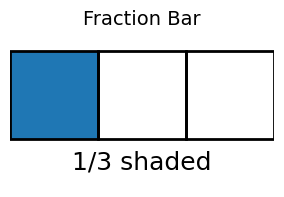


####################################################################################################
Running problem 6/15
####################################################################################################


CONDITION B: Classification Only: Topic/domain metadata, no method card guidance
Problem ID: P06
Problem: Show that 3 * 7 + 3 * 9 is the same as 7 + 7 + 7 + 9 + 9 + 9


------------------------------------------------------------------------------------------
Classification Signal from Elasticsearch
------------------------------------------------------------------------------------------

Score: 0.62641335 | Topic: e_exponentiation | Domain: arithmetic-operations | Doc: arithmetic-operations__e_exponentiation-p001
Score: 0.6248069 | Topic: p_product | Domain: arithmetic-operations | Doc: arithmetic-operations__p_product-p001
Score: 0.62218285 | Topic: s_sum | Domain: arithmetic-operations | Doc: arithmetic-operations__s_sum-p001



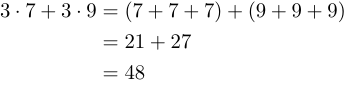


####################################################################################################
Running problem 7/15
####################################################################################################


CONDITION B: Classification Only: Topic/domain metadata, no method card guidance
Problem ID: P07
Problem: In a proper fraction, the difference between the numerator and denominator is 5. If the denominator is 7, what is the fraction?


------------------------------------------------------------------------------------------
Classification Signal from Elasticsearch
------------------------------------------------------------------------------------------

Score: 0.77135897 | Topic: p_proper_fraction | Domain: fractions-decimals | Doc: fractions-decimals__p_proper_fraction-p002
Score: 0.76488376 | Topic: p_proper_fraction | Domain: fractions-decimals | Doc: fractions-decimals__p_proper_fraction-p001
Score: 0.71748185 | Topic: p_proper_fraction | Domain: fractions-d


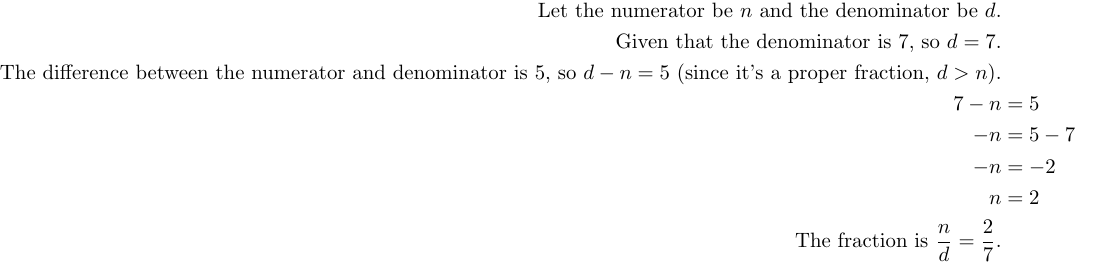


####################################################################################################
Running problem 8/15
####################################################################################################


CONDITION B: Classification Only: Topic/domain metadata, no method card guidance
Problem ID: P08
Problem: What is 1/8 of 16


------------------------------------------------------------------------------------------
Classification Signal from Elasticsearch
------------------------------------------------------------------------------------------

Score: 0.59877014 | Topic: c_converting_fractions_decimals | Domain: fractions-decimals | Doc: fractions-decimals__c_converting_fractions_decimals-p002
Score: 0.59734344 | Topic: t_thousandth | Domain: fractions-decimals | Doc: fractions-decimals__t_thousandth-p001
Score: 0.5958979 | Topic: f_fraction_decimal_chart | Domain: fractions-decimals | Doc: fractions-decimals__f_fraction_decimal_chart-p002



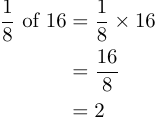


####################################################################################################
Running problem 9/15
####################################################################################################


CONDITION B: Classification Only: Topic/domain metadata, no method card guidance
Problem ID: P09
Problem: The sum of 0.5 and 1.7 is


------------------------------------------------------------------------------------------
Classification Signal from Elasticsearch
------------------------------------------------------------------------------------------

Score: 0.6196549 | Topic: m_mixed_number | Domain: fractions-decimals | Doc: fractions-decimals__m_mixed_number-p002
Score: 0.61845994 | Topic: s_sum | Domain: arithmetic-operations | Doc: arithmetic-operations__s_sum-p001
Score: 0.6165011 | Topic: i_improper_fraction | Domain: fractions-decimals | Doc: fractions-decimals__i_improper_fraction-p001



####################################################################################################
Running problem 10/15
####################################################################################################


CONDITION B: Classification Only: Topic/domain metadata, no method card guidance
Problem ID: P10
Problem: The top length is a square is 7cm, what is the perimeter?


------------------------------------------------------------------------------------------
Classification Signal from Elasticsearch
------------------------------------------------------------------------------------------

Score: 0.6843953 | Topic: p_perimeter | Domain: area-perimeter | Doc: area-perimeter__p_perimeter-p002
Score: 0.66611886 | Topic: m_mensuration | Domain: area-perimeter | Doc: area-perimeter__m_mensuration-p001
Score: 0.6581342 | Topic: p_perimeter | Domain: area-perimeter | Doc: area-perimeter__p_perimeter-p001



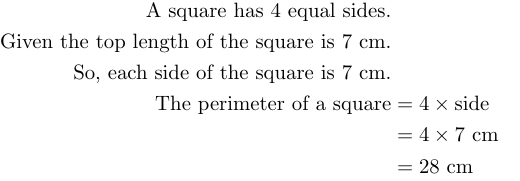


####################################################################################################
Running problem 11/15
####################################################################################################


CONDITION B: Classification Only: Topic/domain metadata, no method card guidance
Problem ID: P11
Problem: Show the largest to the smallest fraction and why they are so, 1/2, 1/4, 1/3, 1/5


------------------------------------------------------------------------------------------
Classification Signal from Elasticsearch
------------------------------------------------------------------------------------------

Score: 0.70217276 | Topic: e_egyptian_fraction | Domain: fractions-decimals | Doc: fractions-decimals__e_egyptian_fraction-p001
Score: 0.69676995 | Topic: u_unit_fraction | Domain: fractions-decimals | Doc: fractions-decimals__u_unit_fraction-p002
Score: 0.6870134 | Topic: s_simplifying_fractions | Domain: fractions-decimals | Doc: fractions-decimals__s_sim


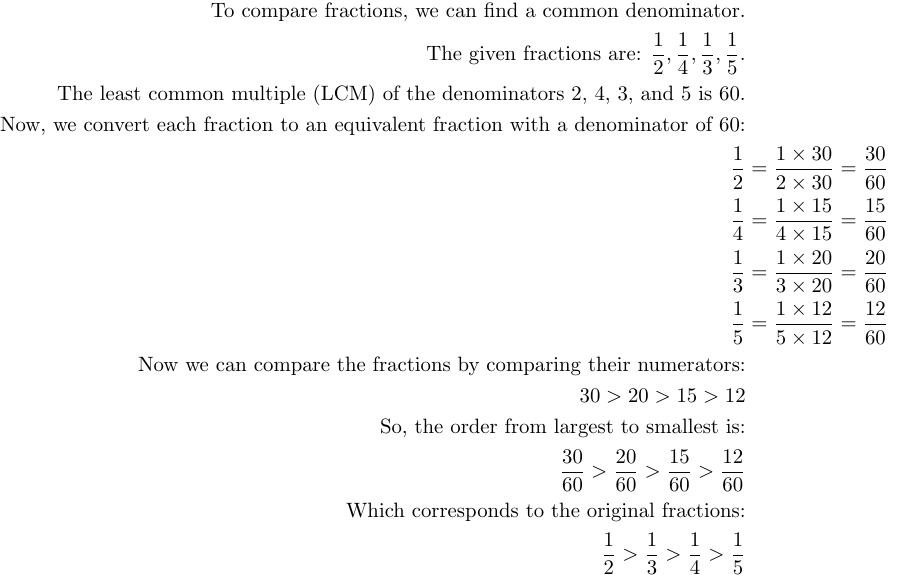


####################################################################################################
Running problem 12/15
####################################################################################################


CONDITION B: Classification Only: Topic/domain metadata, no method card guidance
Problem ID: P12
Problem: Draw A U B if A = {1,5,6}, B = {a,c,d}


------------------------------------------------------------------------------------------
Classification Signal from Elasticsearch
------------------------------------------------------------------------------------------

Score: 0.6957648 | Topic: c_cup | Domain: set-theory | Doc: set-theory__c_cup-p002
Score: 0.6882458 | Topic: u_union | Domain: set-theory | Doc: set-theory__u_union-p001
Score: 0.6838386 | Topic: u_union | Domain: set-theory | Doc: set-theory__u_union-p002



####################################################################################################
Running problem 13/15
####################################################################################################


CONDITION B: Classification Only: Topic/domain metadata, no method card guidance
Problem ID: P13
Problem: Set A = {Even prime numbers greater than 2}, how many members does set A have?


------------------------------------------------------------------------------------------
Classification Signal from Elasticsearch
------------------------------------------------------------------------------------------

Score: 0.6831758 | Topic: s_set_braces | Domain: set-theory | Doc: set-theory__s_set_braces-p001
Score: 0.67578673 | Topic: c_countable | Domain: set-theory | Doc: set-theory__c_countable-p001
Score: 0.6723573 | Topic: e_element_of_a_set | Domain: set-theory | Doc: set-theory__e_element_of_a_set-p001



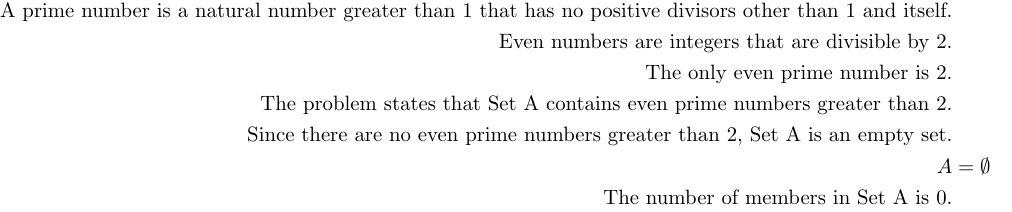


####################################################################################################
Running problem 14/15
####################################################################################################


CONDITION B: Classification Only: Topic/domain metadata, no method card guidance
Problem ID: P14
Problem: Draw a rectangle having 6 regions inside, with 1/2 shaded


------------------------------------------------------------------------------------------
Classification Signal from Elasticsearch
------------------------------------------------------------------------------------------

Score: 0.6007097 | Topic: q_quotient | Domain: arithmetic-operations | Doc: arithmetic-operations__q_quotient-p003
Score: 0.6007097 | Topic: s_sum | Domain: arithmetic-operations | Doc: arithmetic-operations__s_sum-p003
Score: 0.60047984 | Topic: a_area_irregular_polygons | Domain: area-perimeter | Doc: area-perimeter__a_area_irregular_polygons-p001



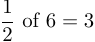

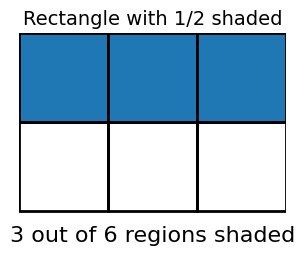


####################################################################################################
Running problem 15/15
####################################################################################################


CONDITION B: Classification Only: Topic/domain metadata, no method card guidance
Problem ID: P15
Problem: The mixed number 7 2/5 written as an improper fraction is


------------------------------------------------------------------------------------------
Classification Signal from Elasticsearch
------------------------------------------------------------------------------------------

Score: 0.7374382 | Topic: m_mixed_number | Domain: fractions-decimals | Doc: fractions-decimals__m_mixed_number-p003
Score: 0.7227895 | Topic: m_mixed_number | Domain: fractions-decimals | Doc: fractions-decimals__m_mixed_number-p001
Score: 0.72033834 | Topic: i_improper_fraction | Domain: fractions-decimals | Doc: fractions-decimals__i_improper_fraction-p001



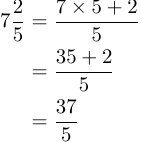


####################################################################################################
FINISHED CONDITION B TEST RUN
####################################################################################################



In [ ]:
run_all_problems_for_condition('B')


####################################################################################################
STARTING CONDITION C TEST RUN
Total problems: 15
####################################################################################################


####################################################################################################
Running problem 1/15
####################################################################################################


CONDITION C: Full Pipeline: Classification/retrieval, guidance selection, method-conditioned solve
Problem ID: P01
Problem: Add 1/2 + 1/5


========== Retrieved Method Context ==========
Score: 0.69088745 | Topic: m_mixed_number | Domain: fractions-decimals | Doc: fractions-decimals__m_mixed_number-p002
Score: 0.66497064 | Topic: f_fractions_addition | Domain: fractions-decimals | Doc: fractions-decimals__f_fractions_addition-p002
Score: 0.6509206 | Topic: f_fractions_addition | Domain: fractions-decimals | Doc: fra


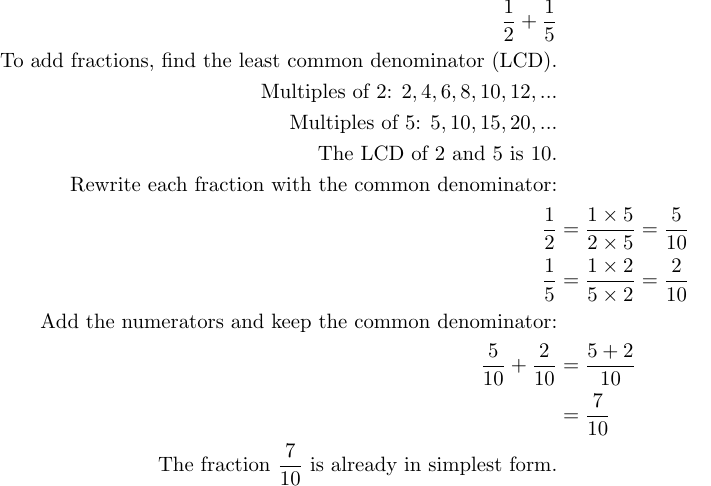


####################################################################################################
Running problem 2/15
####################################################################################################


CONDITION C: Full Pipeline: Classification/retrieval, guidance selection, method-conditioned solve
Problem ID: P02
Problem: Multiply 3/4 by 2/5


========== Retrieved Method Context ==========
Score: 0.70102024 | Topic: e_equivalent_fractions | Domain: fractions-decimals | Doc: fractions-decimals__e_equivalent_fractions-p002
Score: 0.67506814 | Topic: m_mixed_number | Domain: fractions-decimals | Doc: fractions-decimals__m_mixed_number-p002
Score: 0.66949725 | Topic: f_fractions_multiplication | Domain: fractions-decimals | Doc: fractions-decimals__f_fractions_multiplication-p002


========== Retrieval Gate ==========
Top retrieval score: 0.70102024
Threshold: 0.67
Use retrieval: True
Retreival score satisfied.


========== Selected Retrieval Guidance ==========
U


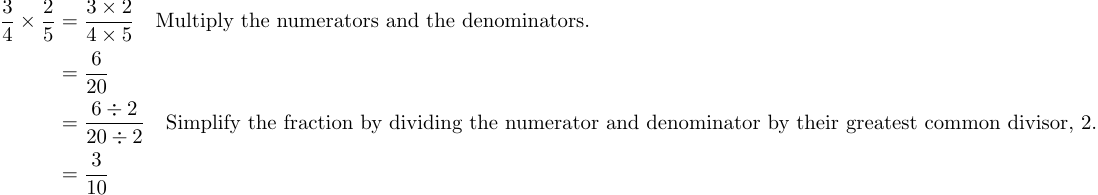


####################################################################################################
Running problem 3/15
####################################################################################################


CONDITION C: Full Pipeline: Classification/retrieval, guidance selection, method-conditioned solve
Problem ID: P03
Problem: The fraction 3/4 written as a decimal is


========== Retrieved Method Context ==========
Score: 0.7162106 | Topic: d_decimal_fraction_percentage | Domain: fractions-decimals | Doc: fractions-decimals__d_decimal_fraction_percentage-p001
Score: 0.71258044 | Topic: c_converting_fractions_decimals | Domain: fractions-decimals | Doc: fractions-decimals__c_converting_fractions_decimals-p001
Score: 0.7060766 | Topic: d_decimal | Domain: fractions-decimals | Doc: fractions-decimals__d_decimal-p001


========== Retrieval Gate ==========
Top retrieval score: 0.7162106
Threshold: 0.67
Use retrieval: True
Retreival score satisfied.


========== Selected


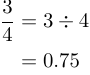


####################################################################################################
Running problem 4/15
####################################################################################################


CONDITION C: Full Pipeline: Classification/retrieval, guidance selection, method-conditioned solve
Problem ID: P04
Problem: If R = {a,b,c,d,e,f}, draw the set that is not a subset of R


========== Retrieved Method Context ==========
Score: 0.67028904 | Topic: s_subset | Domain: set-theory | Doc: set-theory__s_subset-p002
Score: 0.668005 | Topic: i_intersection | Domain: set-theory | Doc: set-theory__i_intersection-p002
Score: 0.6619897 | Topic: p_proper_subset | Domain: set-theory | Doc: set-theory__p_proper_subset-p001


========== Retrieval Gate ==========
Top retrieval score: 0.67028904
Threshold: 0.67
Use retrieval: True
Retreival score satisfied.


========== Selected Retrieval Guidance ==========
Use retrieval: True
Selected docs: ['set-theory__s_subset-p00


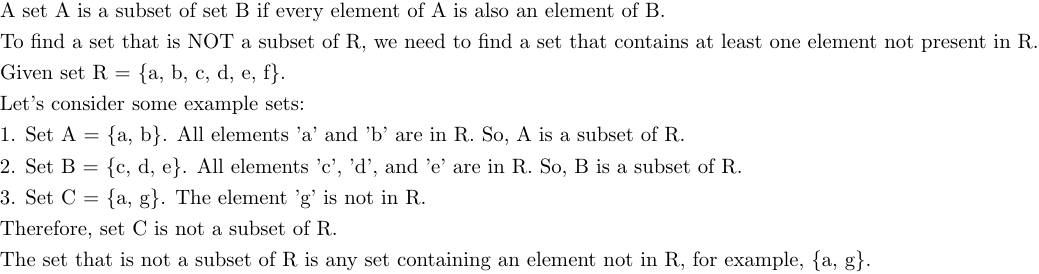


####################################################################################################
Running problem 5/15
####################################################################################################


CONDITION C: Full Pipeline: Classification/retrieval, guidance selection, method-conditioned solve
Problem ID: P05
Problem: Draw a rectangular shape that shows the shading of 1/3


========== Retrieved Method Context ==========
Score: 0.6185677 | Topic: f_fraction_number_line | Domain: fractions-decimals | Doc: fractions-decimals__f_fraction_number_line-p001
Score: 0.61370826 | Topic: d_decimal_fraction_percentage | Domain: fractions-decimals | Doc: fractions-decimals__d_decimal_fraction_percentage-p003
Score: 0.6094401 | Topic: c_converting_fractions_decimals | Domain: fractions-decimals | Doc: fractions-decimals__c_converting_fractions_decimals-p002


========== Direct Visual Renderer ==========
Detected visual kind: fraction_bar
Skipped guidance selector and so

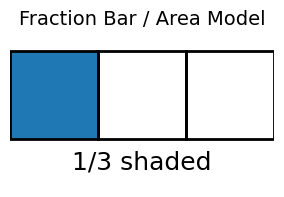


####################################################################################################
Running problem 6/15
####################################################################################################


CONDITION C: Full Pipeline: Classification/retrieval, guidance selection, method-conditioned solve
Problem ID: P06
Problem: Show that 3 * 7 + 3 * 9 is the same as 7 + 7 + 7 + 9 + 9 + 9


========== Retrieved Method Context ==========
Score: 0.62641335 | Topic: e_exponentiation | Domain: arithmetic-operations | Doc: arithmetic-operations__e_exponentiation-p001
Score: 0.6248069 | Topic: p_product | Domain: arithmetic-operations | Doc: arithmetic-operations__p_product-p001
Score: 0.62218285 | Topic: s_sum | Domain: arithmetic-operations | Doc: arithmetic-operations__s_sum-p001


========== Retrieval Gate ==========
Top retrieval score: 0.62641335
Threshold: 0.67
Use retrieval: False
Skipped guidance selector LLM call.


========== Selected Retrieval Guidance ========


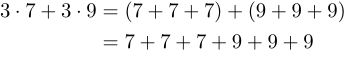


####################################################################################################
Running problem 7/15
####################################################################################################


CONDITION C: Full Pipeline: Classification/retrieval, guidance selection, method-conditioned solve
Problem ID: P07
Problem: In a proper fraction, the difference between the numerator and denominator is 5. If the denominator is 7, what is the fraction?


========== Retrieved Method Context ==========
Score: 0.77135897 | Topic: p_proper_fraction | Domain: fractions-decimals | Doc: fractions-decimals__p_proper_fraction-p002
Score: 0.76488376 | Topic: p_proper_fraction | Domain: fractions-decimals | Doc: fractions-decimals__p_proper_fraction-p001
Score: 0.71748185 | Topic: p_proper_fraction | Domain: fractions-decimals | Doc: fractions-decimals__p_proper_fraction-p003


========== Retrieval Gate ==========
Top retrieval score: 0.77135897
Threshold: 0.67
Use retrieval:


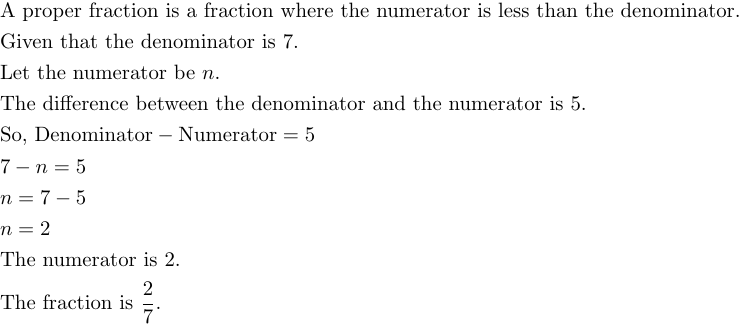


####################################################################################################
Running problem 8/15
####################################################################################################


CONDITION C: Full Pipeline: Classification/retrieval, guidance selection, method-conditioned solve
Problem ID: P08
Problem: What is 1/8 of 16


========== Retrieved Method Context ==========
Score: 0.59877014 | Topic: c_converting_fractions_decimals | Domain: fractions-decimals | Doc: fractions-decimals__c_converting_fractions_decimals-p002
Score: 0.59734344 | Topic: t_thousandth | Domain: fractions-decimals | Doc: fractions-decimals__t_thousandth-p001
Score: 0.5958979 | Topic: f_fraction_decimal_chart | Domain: fractions-decimals | Doc: fractions-decimals__f_fraction_decimal_chart-p002


========== Retrieval Gate ==========
Top retrieval score: 0.59877014
Threshold: 0.67
Use retrieval: False
Skipped guidance selector LLM call.


========== Selected Retrieval Guid


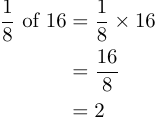


####################################################################################################
Running problem 9/15
####################################################################################################


CONDITION C: Full Pipeline: Classification/retrieval, guidance selection, method-conditioned solve
Problem ID: P09
Problem: The sum of 0.5 and 1.7 is


========== Retrieved Method Context ==========
Score: 0.6196549 | Topic: m_mixed_number | Domain: fractions-decimals | Doc: fractions-decimals__m_mixed_number-p002
Score: 0.61845994 | Topic: s_sum | Domain: arithmetic-operations | Doc: arithmetic-operations__s_sum-p001
Score: 0.6165011 | Topic: i_improper_fraction | Domain: fractions-decimals | Doc: fractions-decimals__i_improper_fraction-p001


========== Retrieval Gate ==========
Top retrieval score: 0.6196549
Threshold: 0.67
Use retrieval: False
Skipped guidance selector LLM call.


========== Selected Retrieval Guidance ==========
Use retrieval: False
Selected 


####################################################################################################
Running problem 10/15
####################################################################################################


CONDITION C: Full Pipeline: Classification/retrieval, guidance selection, method-conditioned solve
Problem ID: P10
Problem: The top length is a square is 7cm, what is the perimeter?


========== Retrieved Method Context ==========
Score: 0.6843953 | Topic: p_perimeter | Domain: area-perimeter | Doc: area-perimeter__p_perimeter-p002
Score: 0.66611886 | Topic: m_mensuration | Domain: area-perimeter | Doc: area-perimeter__m_mensuration-p001
Score: 0.6581342 | Topic: p_perimeter | Domain: area-perimeter | Doc: area-perimeter__p_perimeter-p001


========== Retrieval Gate ==========
Top retrieval score: 0.6843953
Threshold: 0.67
Use retrieval: True
Retreival score satisfied.


========== Selected Retrieval Guidance ==========
Use retrieval: True
Selected docs: ['area-p


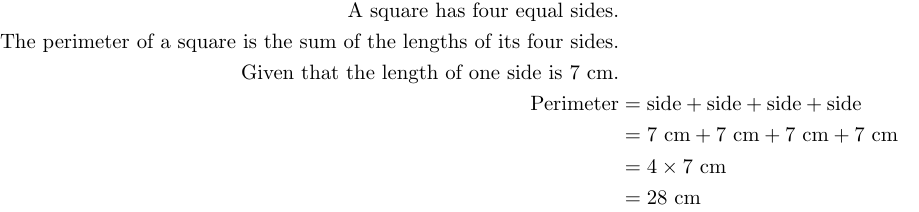


####################################################################################################
Running problem 11/15
####################################################################################################


CONDITION C: Full Pipeline: Classification/retrieval, guidance selection, method-conditioned solve
Problem ID: P11
Problem: Show the largest to the smallest fraction and why they are so, 1/2, 1/4, 1/3, 1/5


========== Retrieved Method Context ==========
Score: 0.70217276 | Topic: e_egyptian_fraction | Domain: fractions-decimals | Doc: fractions-decimals__e_egyptian_fraction-p001
Score: 0.69676995 | Topic: u_unit_fraction | Domain: fractions-decimals | Doc: fractions-decimals__u_unit_fraction-p002
Score: 0.6870134 | Topic: s_simplifying_fractions | Domain: fractions-decimals | Doc: fractions-decimals__s_simplifying_fractions-p002


========== Retrieval Gate ==========
Top retrieval score: 0.70217276
Threshold: 0.67
Use retrieval: True
Retreival score satisfied.




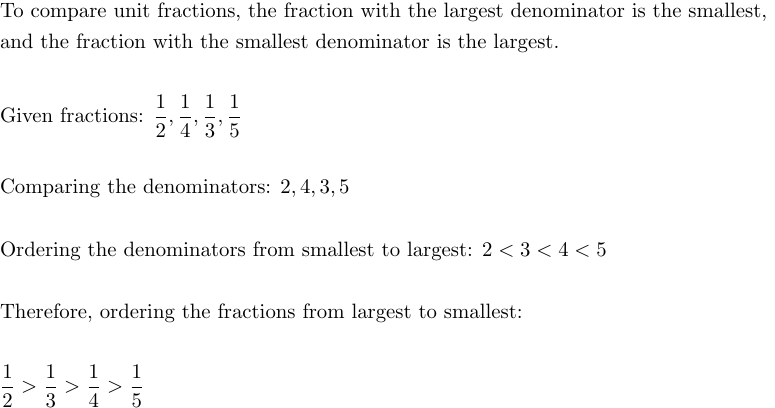


####################################################################################################
Running problem 12/15
####################################################################################################


CONDITION C: Full Pipeline: Classification/retrieval, guidance selection, method-conditioned solve
Problem ID: P12
Problem: Draw A U B if A = {1,5,6}, B = {a,c,d}


========== Retrieved Method Context ==========
Score: 0.6957648 | Topic: c_cup | Domain: set-theory | Doc: set-theory__c_cup-p002
Score: 0.6882458 | Topic: u_union | Domain: set-theory | Doc: set-theory__u_union-p001
Score: 0.6838386 | Topic: u_union | Domain: set-theory | Doc: set-theory__u_union-p002


========== Direct Visual Renderer ==========
Detected visual kind: venn2
Skipped guidance selector and solver LLM for this visual-only prompt.
Rendering with matplotlib.



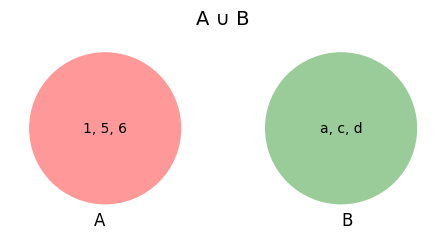


####################################################################################################
Running problem 13/15
####################################################################################################


CONDITION C: Full Pipeline: Classification/retrieval, guidance selection, method-conditioned solve
Problem ID: P13
Problem: Set A = {Even prime numbers greater than 2}, how many members does set A have?


========== Retrieved Method Context ==========
Score: 0.6831758 | Topic: s_set_braces | Domain: set-theory | Doc: set-theory__s_set_braces-p001
Score: 0.67578673 | Topic: c_countable | Domain: set-theory | Doc: set-theory__c_countable-p001
Score: 0.6723573 | Topic: e_element_of_a_set | Domain: set-theory | Doc: set-theory__e_element_of_a_set-p001


========== Retrieval Gate ==========
Top retrieval score: 0.6831758
Threshold: 0.67
Use retrieval: True
Retreival score satisfied.


========== Selected Retrieval Guidance ==========
Use retrieval: True
Selected docs:


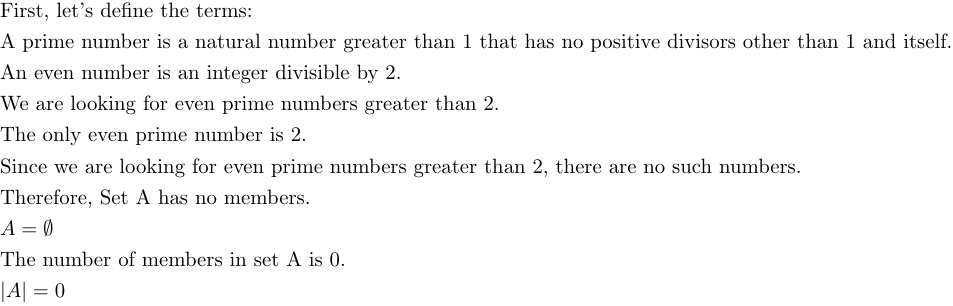


####################################################################################################
Running problem 14/15
####################################################################################################


CONDITION C: Full Pipeline: Classification/retrieval, guidance selection, method-conditioned solve
Problem ID: P14
Problem: Draw a rectangle having 6 regions inside, with 1/2 shaded


========== Retrieved Method Context ==========
Score: 0.6007097 | Topic: q_quotient | Domain: arithmetic-operations | Doc: arithmetic-operations__q_quotient-p003
Score: 0.6007097 | Topic: s_sum | Domain: arithmetic-operations | Doc: arithmetic-operations__s_sum-p003
Score: 0.60047984 | Topic: a_area_irregular_polygons | Domain: area-perimeter | Doc: area-perimeter__a_area_irregular_polygons-p001


========== Direct Visual Renderer ==========
Detected visual kind: box_grid
Skipped guidance selector and solver LLM for this visual-only prompt.
Rendering with matplotlib.



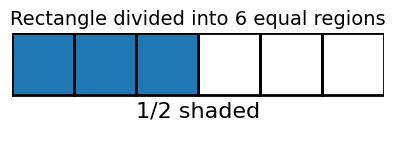


####################################################################################################
Running problem 15/15
####################################################################################################


CONDITION C: Full Pipeline: Classification/retrieval, guidance selection, method-conditioned solve
Problem ID: P15
Problem: The mixed number 7 2/5 written as an improper fraction is


========== Retrieved Method Context ==========
Score: 0.7374382 | Topic: m_mixed_number | Domain: fractions-decimals | Doc: fractions-decimals__m_mixed_number-p003
Score: 0.7227895 | Topic: m_mixed_number | Domain: fractions-decimals | Doc: fractions-decimals__m_mixed_number-p001
Score: 0.72033834 | Topic: i_improper_fraction | Domain: fractions-decimals | Doc: fractions-decimals__i_improper_fraction-p001


========== Retrieval Gate ==========
Top retrieval score: 0.7374382
Threshold: 0.67
Use retrieval: True
Retreival score satisfied.


========== Selected Retrieval Guidance ======


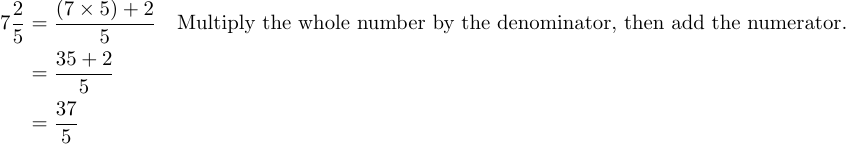


####################################################################################################
FINISHED CONDITION C TEST RUN
####################################################################################################



In [ ]:
run_all_problems_for_condition('C')

### **--- END RAG tests ---**

### **--- Image Problem Detection and Extraction Test Cases ---**

In [ ]:
import PIL.Image
import ast, io, base64

In [ ]:
from google.colab import userdata
from openai import OpenAI

dashscope_key = userdata.get('DASHSCOPE_API_KEY')

client = OpenAI(
    # If the environment variable is not set, replace it with your Model Studio API key: api_key="sk-xxx"
    api_key=dashscope_key,
    base_url="https://dashscope-intl.aliyuncs.com/compatible-mode/v1",
)

In [ ]:
SYSTEM_PROMPT = """You are a math solver. Solve the given problem step by step.
Rules:
- Do the step by step working for each problem.
- State the rule, law, formula or theorem used before solving it like "Formula Used: FORMULAHERE".
- Provide all responses in English only
- Output ONLY LaTeX, no prose
- Wrap everything in $$\begin{aligned}...\end{aligned}$$
- Use &= for alignment
- Use \\\\ for new lines between steps
- No explanation, no text outside the LaTeX block"""

def solve_and_render(problem: str):
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": f"Problem: {problem}"}
    ]

    completion = client.chat.completions.create(
        model="deepseek-v3.2",
        messages=messages,
        stream=True
    )

    full_response = ""
    is_answering = False

    for chunk in completion:
        delta = chunk.choices[0].delta

        # Print thinking process if present
        if hasattr(delta, "reasoning_content") and delta.reasoning_content:
            if not is_answering:
                print(delta.reasoning_content, end="", flush=True)

        # Collect the actual LaTeX response
        if hasattr(delta, "content") and delta.content:
            if not is_answering:
                is_answering = True
            full_response += delta.content

    # Once stream is complete, render
    extract_and_render(full_response)

<>:7: SyntaxWarning: invalid escape sequence '\e'
<>:7: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_10857/641306356.py:7: SyntaxWarning: invalid escape sequence '\e'
  - Wrap everything in $$\begin{aligned}...\end{aligned}$$


In [ ]:
def extract_problems_from_image(image_path: str, model_name="qwen3.5-flash") -> list:
    image = PIL.Image.open(image_path)

    # Convert image to base64
    buffered = io.BytesIO()
    image.save(buffered, format="PNG")
    image_b64 = base64.b64encode(buffered.getvalue()).decode("utf-8")

    prompt = """Extract all math problems from this image along with thier given instructions.
Rules:
- Carefully read the instructions so you know what to solve for or what to find for the given expression
- Return ONLY a Python list of strings, one problem per item
- Each problem should be a clean text representation
- No explanations, no numbering, just the list with the short instruction on what to to with the given problem
Example: solve for x / find y / complete the square for ["2x + 3 = 7", "sin(x) = 0.5"]"""

    response = client.chat.completions.create(
        model=model_name,
        messages=[
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": prompt},
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": f"data:image/png;base64,{image_b64}"
                        }
                    }
                ]
            }
        ]
    )

    text = response.choices[0].message.content.strip()

    # Remove code fences if present
    text = re.sub(r"```.*?\n", "", text)
    text = text.replace("```", "")

    # Extract the first list found
    match = re.search(r"\[.*\]", text, re.DOTALL)
    if match:
        text = match.group(0)

    return ast.literal_eval(text)


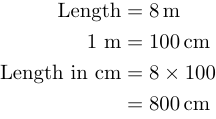


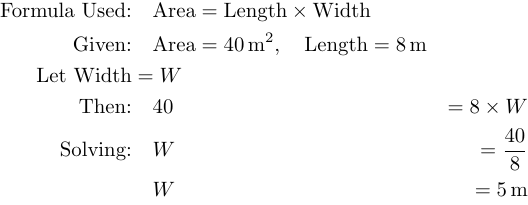


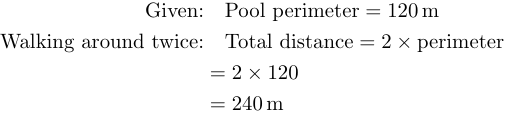

In [ ]:
problems = extract_problems_from_image("math-problems.png")

if not problems:
    print("No problems detected.")
else:
    for problem in problems:
        try:
            solve_and_render(problem)
        except Exception as e:
            print(f"Failed on: {problem}")
            print(e)

In [ ]:
"""
LEDGER_INDEX = "ledger-v1"


from datetime import datetime, timezone


MANUAL_LEDGER_ATTEMPTS = [
    {
        "record_id": "manual-ledger-P01-fraction-addition",
        "source": "manual_demo",
        "condition": "manual_logged_attempt",
        "problem_id": "P01",
        "problem_text": "Add 1/2 + 1/5",
        "normalized_problem": "Add two unlike fractions: one half plus one fifth.",
        "expected_area": "fractions",
        "domain": "primary_school_math",
        "problem_type": "fraction_addition_unlike_denominators",
        "retrieved_doc_ids": [],
        "retrieval_score": None,
        "solver_model": "manual_record",
        "resolution_summary": "Use a common denominator of 10. Convert 1/2 to 5/10 and 1/5 to 2/10, then add the numerators.",
        "final_answer": "7/10",
        "final_answer_latex": r"$$\begin{aligned} \frac{1}{2} + \frac{1}{5} &= \frac{5}{10} + \frac{2}{10} \\ &= \frac{7}{10} \end{aligned}$$",
        "render_status": "manual_success",
        "notes": "Manually logged to demonstrate semantic retrieval over solved attempts."
    },
    {
        "record_id": "manual-ledger-P03-fraction-to-decimal",
        "source": "manual_demo",
        "condition": "manual_logged_attempt",
        "problem_id": "P03",
        "problem_text": "The fraction 3/4 written as a decimal is",
        "normalized_problem": "Convert the fraction three quarters into decimal form.",
        "expected_area": "fractions-decimals",
        "domain": "primary_school_math",
        "problem_type": "fraction_to_decimal",
        "retrieved_doc_ids": [],
        "retrieval_score": None,
        "solver_model": "manual_record",
        "resolution_summary": "Divide the numerator by the denominator. Three divided by four equals zero point seven five.",
        "final_answer": "0.75",
        "final_answer_latex": r"$$\begin{aligned} \frac{3}{4} &= 3 \div 4 \\ &= 0.75 \end{aligned}$$",
        "render_status": "manual_success",
        "notes": "Manually logged to demonstrate semantic retrieval over solved attempts."
    },
    {
        "record_id": "manual-ledger-P10-square-perimeter",
        "source": "manual_demo",
        "condition": "manual_logged_attempt",
        "problem_id": "P10",
        "problem_text": "The top length is a square is 7cm, what is the perimeter?",
        "normalized_problem": "A square has side length 7 cm. Find its perimeter.",
        "expected_area": "perimeter",
        "domain": "primary_school_math",
        "problem_type": "square_perimeter",
        "retrieved_doc_ids": [],
        "retrieval_score": None,
        "solver_model": "manual_record",
        "resolution_summary": "A square has four equal sides, so multiply the side length by four.",
        "final_answer": "28 cm",
        "final_answer_latex": r"$$\begin{aligned} P &= 4 \times s \\ P &= 4 \times 7 \\ P &= 28\text{ cm} \end{aligned}$$",
        "render_status": "manual_success",
        "notes": "Manually logged to demonstrate semantic retrieval over solved attempts."
    },
    {
        "record_id": "manual-ledger-P13-empty-set",
        "source": "manual_demo",
        "condition": "manual_logged_attempt",
        "problem_id": "P13",
        "problem_text": "Set A = {Even prime numbers greater than 2}, how many members does set A have?",
        "normalized_problem": "Find the number of even prime numbers greater than two.",
        "expected_area": "set-theory",
        "domain": "primary_school_math",
        "problem_type": "empty_set_reasoning",
        "retrieved_doc_ids": [],
        "retrieval_score": None,
        "solver_model": "manual_record",
        "resolution_summary": "The only even prime number is 2. Since the set asks for even prime numbers greater than 2, there are no members.",
        "final_answer": "0 members",
        "final_answer_latex": r"$$\begin{aligned} A &= \{\text{even prime numbers greater than }2\} \\ A &= \varnothing \\ n(A) &= 0 \end{aligned}$$",
        "render_status": "manual_success",
        "notes": "Manually logged to demonstrate semantic retrieval over solved attempts."
    },
    {
        "record_id": "manual-ledger-P15-mixed-to-improper",
        "source": "manual_demo",
        "condition": "manual_logged_attempt",
        "problem_id": "P15",
        "problem_text": "The mixed number 7 2/5 written as an improper fraction is",
        "normalized_problem": "Convert the mixed number seven and two fifths to an improper fraction.",
        "expected_area": "mixed-numbers",
        "domain": "primary_school_math",
        "problem_type": "mixed_number_to_improper_fraction",
        "retrieved_doc_ids": [],
        "retrieval_score": None,
        "solver_model": "manual_record",
        "resolution_summary": "Multiply the whole number by the denominator, add the numerator, and keep the same denominator.",
        "final_answer": "37/5",
        "final_answer_latex": r"$$\begin{aligned} 7\frac{2}{5} &= \frac{7 \times 5 + 2}{5} \\ &= \frac{35 + 2}{5} \\ &= \frac{37}{5} \end{aligned}$$",
        "render_status": "manual_success",
        "notes": "Manually logged to demonstrate semantic retrieval over solved attempts."
    }
]


def build_ledger_embedding_text(attempt: dict) -> str:
    """
    Builds the text used for semantic embedding.

    This combines the problem wording with the resolution summary so that
    later searches can retrieve the attempt by problem meaning or method meaning.
    """

    return "\n".join([
        f"Problem: {attempt.get('problem_text', '')}",
        f"Normalized problem: {attempt.get('normalized_problem', '')}",
        f"Expected area: {attempt.get('expected_area', '')}",
        f"Problem type: {attempt.get('problem_type', '')}",
        f"Resolution summary: {attempt.get('resolution_summary', '')}",
        f"Final answer: {attempt.get('final_answer', '')}"
    ])


def index_manual_ledger_attempts(attempts: list = MANUAL_LEDGER_ATTEMPTS):
    """
    Indexes manual resolution attempts into ledger-v1.

    Re-running this cell is safe because each document uses a fixed record_id.
    Elasticsearch will overwrite the same manual records instead of duplicating them.
    """

    for attempt in attempts:
        embedding_text = build_ledger_embedding_text(attempt)
        vector = embed_query(embedding_text)

        doc = {
            **attempt,
            "timestamp": datetime.now(timezone.utc).isoformat(),
            "embedding_text": embedding_text,
            "problem_embedding": vector
        }

        elastic_request(
            method="PUT",
            path=f"/{LEDGER_INDEX}/_doc/{attempt['record_id']}?refresh=wait_for",
            body=doc,
            expected=(200, 201)
        )

        print(f"[OK] Indexed manual ledger attempt: {attempt['record_id']}")


index_manual_ledger_attempts()
"""

In [ ]:
"""
def retrieve_resolution_attempts_from_ledger(
    query_text: str,
    k: int = 3,
    num_candidates: int = 50
) -> list:
    """
    Retrieves previous resolution attempts from ledger-v1 using semantic vector search.
    """

    query_vector = embed_query(query_text)

    body = {
        "knn": {
            "field": "problem_embedding",
            "query_vector": query_vector,
            "k": k,
            "num_candidates": num_candidates
        },
        "_source": [
            "record_id",
            "problem_id",
            "problem_text",
            "normalized_problem",
            "expected_area",
            "problem_type",
            "resolution_summary",
            "final_answer",
            "final_answer_latex",
            "condition",
            "source",
            "render_status"
        ]
    }

    resp = elastic_request(
        method="POST",
        path=f"/{LEDGER_INDEX}/_search",
        body=body
    )

    results = []

    for hit in resp.get("hits", {}).get("hits", []):
        source = hit.get("_source", {})

        results.append({
            "score": hit.get("_score"),
            "record_id": source.get("record_id"),
            "problem_id": source.get("problem_id"),
            "problem_text": source.get("problem_text"),
            "normalized_problem": source.get("normalized_problem"),
            "expected_area": source.get("expected_area"),
            "problem_type": source.get("problem_type"),
            "resolution_summary": source.get("resolution_summary"),
            "final_answer": source.get("final_answer"),
            "final_answer_latex": source.get("final_answer_latex"),
            "condition": source.get("condition"),
            "source": source.get("source"),
            "render_status": source.get("render_status")
        })

    return results


def show_ledger_retrieval_demo(query_text: str, k: int = 3):
    """
    Prints semantic retrieval results from ledger-v1 in a readable way.
    """

    print("\n" + "=" * 90)
    print("LEDGER-v1 SEMANTIC RETRIEVAL DEMO")
    print(f"Query: {query_text}")
    print("=" * 90)

    results = retrieve_resolution_attempts_from_ledger(
        query_text=query_text,
        k=k
    )

    if not results:
        print("[WARN] No ledger results found.")
        return []

    for i, result in enumerate(results, start=1):
        print("\n" + "-" * 90)
        print(f"Rank: {i}")
        print(f"Score: {result.get('score')}")
        print(f"Record ID: {result.get('record_id')}")
        print(f"Problem ID: {result.get('problem_id')}")
        print(f"Problem: {result.get('problem_text')}")
        print(f"Problem type: {result.get('problem_type')}")
        print(f"Resolution summary: {result.get('resolution_summary')}")
        print(f"Final answer: {result.get('final_answer')}")
        print("-" * 90)

    return results


# ------------------------------------------------------------
# Demo queries
# ------------------------------------------------------------
# These queries are intentionally worded differently from the stored problems.
# The point is to show semantic retrieval, not exact keyword matching.
# ------------------------------------------------------------

demo_ledger_results_1 = show_ledger_retrieval_demo(
    "How do I add fractions that have different denominators?",
    k=3
)

demo_ledger_results_2 = show_ledger_retrieval_demo(
    "Find the perimeter when a square has a side length of seven centimeters.",
    k=3
)

demo_ledger_results_3 = show_ledger_retrieval_demo(
    "Convert a mixed number into an improper fraction.",
    k=3
)
"""